# Day-ahead Electricity Price Forecasting in Spain

**Course:** Data Science for Electrical Systems – UPC  
**Date:** December 2025

---

## Notebook Structure

This notebook documents the development of a supervised machine learning model for day-ahead electricity price forecasting in the Spanish wholesale market. The work is organised into the following sections:

1. **Data Loading and Preprocessing**  
   Import of historical data from ESIOS/REE; timestamp parsing; treatment of missing values and duplicates.

2. **Exploratory Data Analysis (EDA)**  
   Descriptive statistics; temporal pattern analysis; correlation structure; identification of key price drivers.

3. **Supervised Learning Framework**  
   - 3.1 Problem formulation and target definition  
   - 3.2 Lag feature engineering
   - 3.3 Feature selection methodology and results 
   - 3.4 Temporal train/test split 
   - 3.5 Model training, evaluation, and validation 

---

**Target variable:** `spot_price_spain` (day-ahead hourly marginal price, €/MWh)  
**Temporal resolution:** Hourly  
**Evaluation period:** September 2025 


# Exploratory Data Analysis (EDA)



In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score



In [66]:
# ---------------------------
# Load & clean
# ---------------------------
Dataset = pd.read_csv("dataset.csv", sep=',') #energy in MWh, last column price in eur/MWh

# datetime: make tz-naive (consistent)
Dataset['timestamp'] = pd.to_datetime(Dataset['timestamp'], errors='coerce', utc=True).dt.tz_convert(None)

# Remove NA / duplicates / sort
Dataset = (
    Dataset
    .dropna(subset=['timestamp'])
    .drop_duplicates(subset=['timestamp'])
    .sort_values('timestamp')
    .reset_index(drop=True)
)

Dataset.head() #variables hour, day_of_week and month are considered already, mondays are 0, months go from 1 to 12



,timestamp,scheduled_demand,actual_national_demand,dam_allocated_energy_spain,scheduled_coal,scheduled_combined_cycle,scheduled_wind,scheduled_hydraulic,scheduled_total_import,scheduled_nuclear,...,actual_coal_generation,actual_combined_cycle_generation,actual_wind_generation,actual_hydraulic_generation,actual_nuclear_generation,actual_solar_pv_generation,hour,day_of_week,month,spot_price_spain
0,2022-08-31 22:00:00,25915.0,27690.750000,21730.8,695.00,14748.950,4387.050,615.975,298.8,6869.9,...,685.750000,15237.583333,4423.916667,1222.833333,6901.750000,26.500000,0,3,9,200.00
1,2022-08-31 23:00:00,24494.5,26274.083333,20572.7,750.00,14255.600,4008.900,586.100,325.2,6881.9,...,751.000000,14812.500000,4039.500000,948.583333,6904.416667,26.500000,1,3,9,181.99
2,2022-09-01 00:00:00,23455.0,25140.583333,19453.6,777.50,13644.750,3547.500,536.500,299.9,6873.9,...,813.750000,14522.333333,3361.083333,381.916667,6904.916667,26.166667,2,3,9,178.54
3,2022-09-01 01:00:00,23008.0,24582.416667,18995.7,802.50,13736.500,3188.650,534.600,308.8,6879.9,...,810.500000,14344.583333,2832.750000,363.333333,6907.833333,26.500000,3,3,9,178.54
4,2022-09-01 02:00:00,22737.0,24292.166667,19103.8,816.25,13706.825,2594.225,555.700,308.0,6873.9,...,826.833333,14415.333333,2446.416667,532.750000,6908.333333,26.416667,4,3,9,181.23


In [67]:
# first look at data
Dataset.describe()

,timestamp,scheduled_demand,actual_national_demand,dam_allocated_energy_spain,scheduled_coal,scheduled_combined_cycle,scheduled_wind,scheduled_hydraulic,scheduled_total_import,scheduled_nuclear,...,actual_coal_generation,actual_combined_cycle_generation,actual_wind_generation,actual_hydraulic_generation,actual_nuclear_generation,actual_solar_pv_generation,hour,day_of_week,month,spot_price_spain
count,26304,26302.000000,26221.000000,26289.000000,25080.000000,26266.000000,26266.000000,26266.000000,26178.000000,26266.000000,...,26302.000000,26221.000000,26221.000000,26221.000000,26221.000000,26221.000000,26304.000000,26304.000000,26304.000000,26304.000000
mean,2024-03-01 21:30:00,26407.768468,28216.378582,20203.732276,408.709494,4206.297957,6879.659566,3012.985097,1911.264616,6083.731763,...,390.836749,5102.684035,6885.146076,3109.744004,6093.051645,4685.597373,11.500000,3.005474,6.522696,77.545857
min,2022-08-31 22:00:00,0.000000,2100.666667,80.300000,15.000000,302.900000,301.125000,148.125000,0.200000,142.000000,...,0.000000,672.666667,80.083333,-3690.166667,0.000000,0.000000,0.000000,0.000000,1.000000,-15.000000
25%,2023-06-01 21:45:00,22925.187500,24492.583333,16936.300000,243.000000,1981.137500,3602.518750,1298.737500,888.025000,5095.000000,...,248.916667,2833.916667,3669.333333,832.166667,5106.000000,30.166667,5.750000,1.000000,4.000000,35.010000
50%,2024-03-01 21:30:00,26446.125000,28280.166667,19691.300000,320.000000,3319.712500,6103.775000,2624.050000,1824.650000,6499.400000,...,308.083333,4253.916667,6179.166667,2932.500000,6490.833333,325.333333,11.500000,3.000000,7.000000,84.200000
75%,2024-11-30 21:15:00,29559.687500,31564.000000,23108.700000,487.462500,5689.350000,9496.906250,4355.081250,2808.000000,6945.900000,...,490.895833,6661.416667,9461.083333,5310.750000,6987.416667,9678.750000,17.250000,5.000000,10.000000,113.500000
max,2025-08-31 21:00:00,39866.750000,42126.000000,36294.900000,1655.000000,17054.625000,21271.000000,9393.675000,8100.325000,12101.400000,...,1576.250000,18216.250000,20908.166667,11695.916667,7140.416667,23220.916667,23.000000,6.000000,12.000000,300.000000
std,NaN,4351.479204,4520.717616,4397.696556,233.956958,2994.971911,4083.082989,1997.575420,1176.420914,1073.778279,...,247.173132,3036.824465,4007.116740,3082.350067,1095.668374,6003.637684,6.922318,1.999574,3.449047,49.851867


In [68]:
#actual hydro generation has negative values which at first sight seems like an error, checking the ESIOS website https://www.esios.ree.es/en/analysis/546?vis=1&start_date=01-09-2022T00%3A00&end_date=31-08-2025T23%3A55&compare_start_date=31-08-2022T00%3A00&groupby=hour
# that's because of pumping, so it's not an error but a feature of the data
print("Statistical summary of actual_hydraulic_generation:")
print(Dataset['actual_hydraulic_generation'].describe())
print(f"\nNumber of negative values: {len(Dataset[Dataset['actual_hydraulic_generation'] < 0])}")
print(f"Percentage of negative values: {len(Dataset[Dataset['actual_hydraulic_generation'] < 0]) / len(Dataset) * 100:.2f}%")

Statistical summary of actual_hydraulic_generation:
count    26221.000000
mean      3109.744004
std       3082.350067
min      -3690.166667
25%        832.166667
50%       2932.500000
75%       5310.750000
max      11695.916667
Name: actual_hydraulic_generation, dtype: float64

Number of negative values: 4478
Percentage of negative values: 17.02%


Basic Statistics for Spot Price Spain:
count    26304.000000
mean        77.545857
std         49.851867
min        -15.000000
25%         35.010000
50%         84.200000
75%        113.500000
max        300.000000
Name: spot_price_spain, dtype: float64


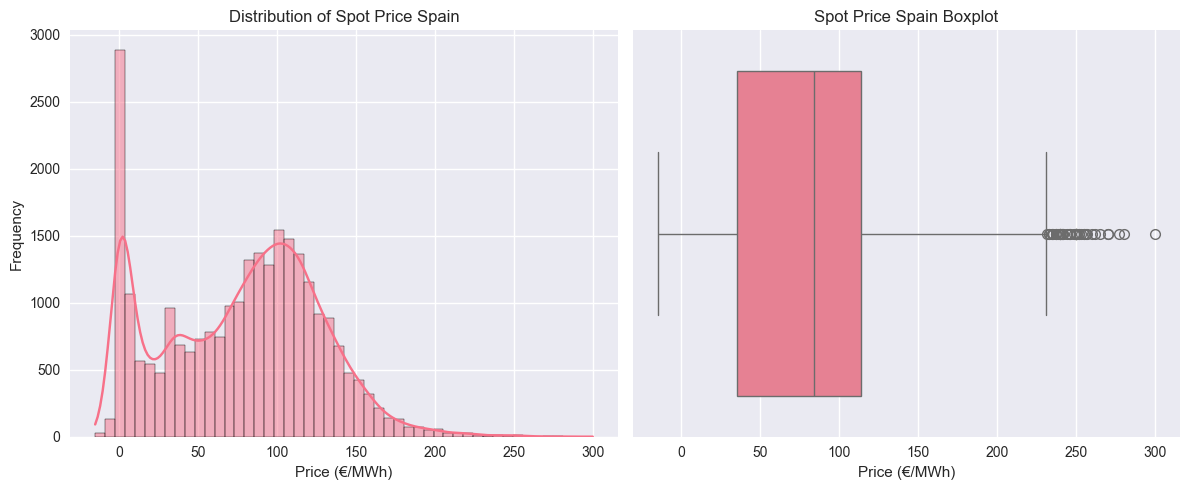

In [69]:
# ---------------------------
# Basic stats & distributions for the price (target variable)
# ---------------------------
print("Basic Statistics for Spot Price Spain:")
print(Dataset['spot_price_spain'].describe())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(Dataset['spot_price_spain'], bins=50, kde=True)
plt.title('Distribution of Spot Price Spain')
plt.xlabel('Price (€/MWh)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(x=Dataset['spot_price_spain'])
plt.title("Spot Price Spain Boxplot")
plt.xlabel('Price (€/MWh)')

plt.tight_layout()
plt.show()


ANALYSIS FOR: scheduled_demand
count    26302.000000
mean     26407.768468
std       4351.479204
min          0.000000
25%      22925.187500
50%      26446.125000
75%      29559.687500
max      39866.750000
Name: scheduled_demand, dtype: float64

Additional Stats:
Skewness: -0.134
Kurtosis: 0.883
Missing values: 2
Zero values: 35 (0.13%)


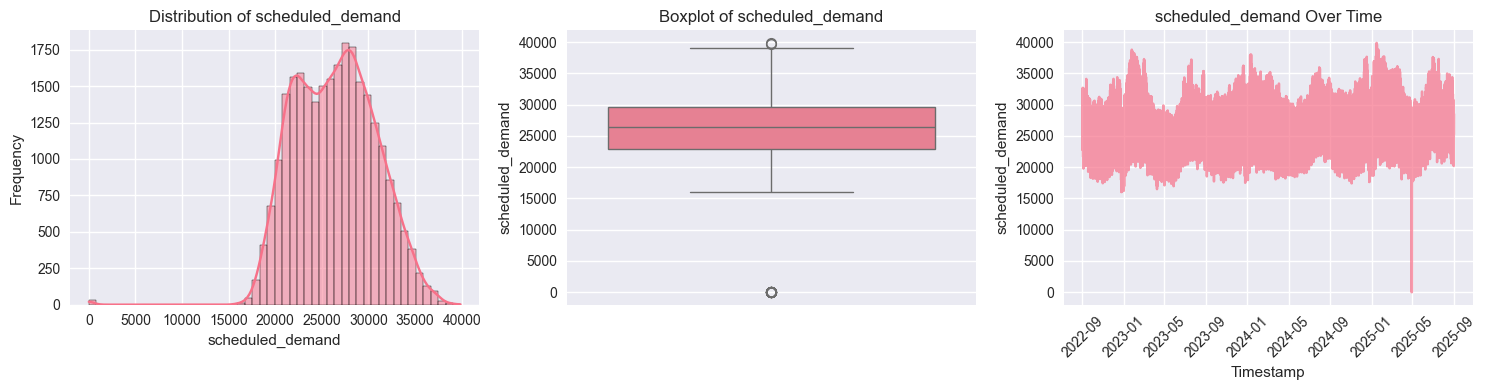


ANALYSIS FOR: actual_national_demand
count    26221.000000
mean     28216.378582
std       4520.717616
min       2100.666667
25%      24492.583333
50%      28280.166667
75%      31564.000000
max      42126.000000
Name: actual_national_demand, dtype: float64

Additional Stats:
Skewness: 0.091
Kurtosis: -0.574
Missing values: 83
Zero values: 0 (0.00%)


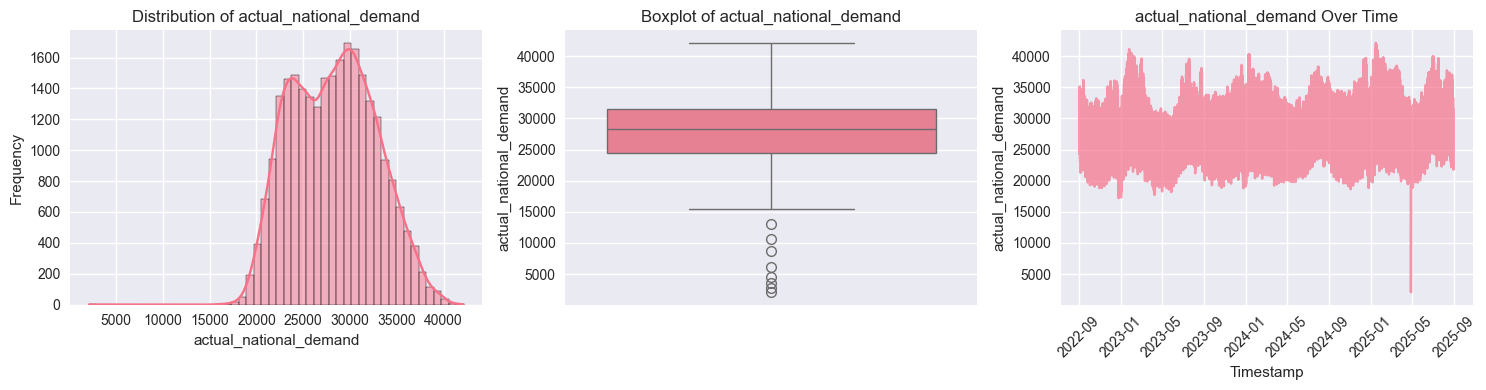


ANALYSIS FOR: dam_allocated_energy_spain
count    26289.000000
mean     20203.732276
std       4397.696556
min         80.300000
25%      16936.300000
50%      19691.300000
75%      23108.700000
max      36294.900000
Name: dam_allocated_energy_spain, dtype: float64

Additional Stats:
Skewness: 0.379
Kurtosis: -0.047
Missing values: 15
Zero values: 0 (0.00%)


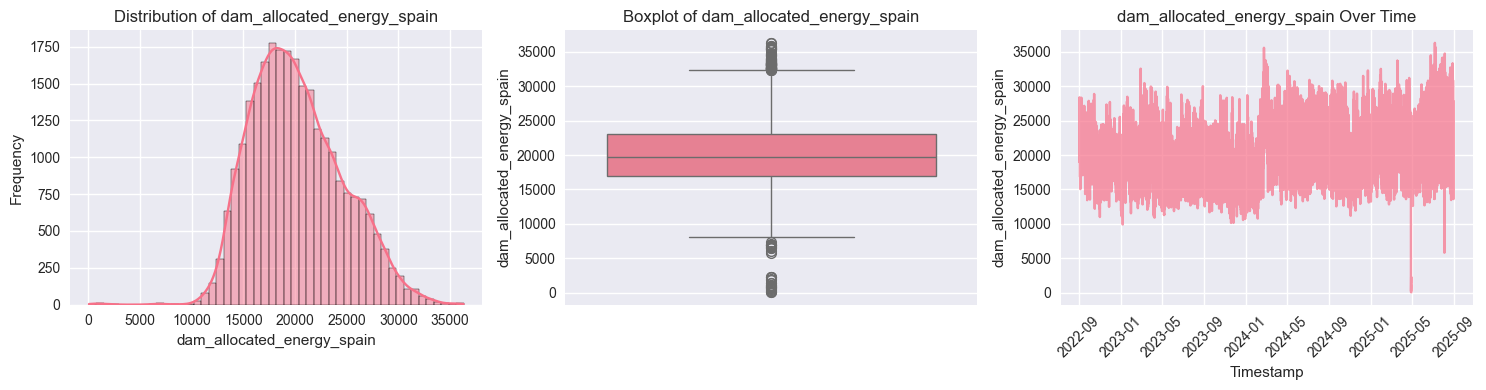


ANALYSIS FOR: scheduled_coal
count    25080.000000
mean       408.709494
std        233.956958
min         15.000000
25%        243.000000
50%        320.000000
75%        487.462500
max       1655.000000
Name: scheduled_coal, dtype: float64

Additional Stats:
Skewness: 1.969
Kurtosis: 4.700
Missing values: 1224
Zero values: 0 (0.00%)


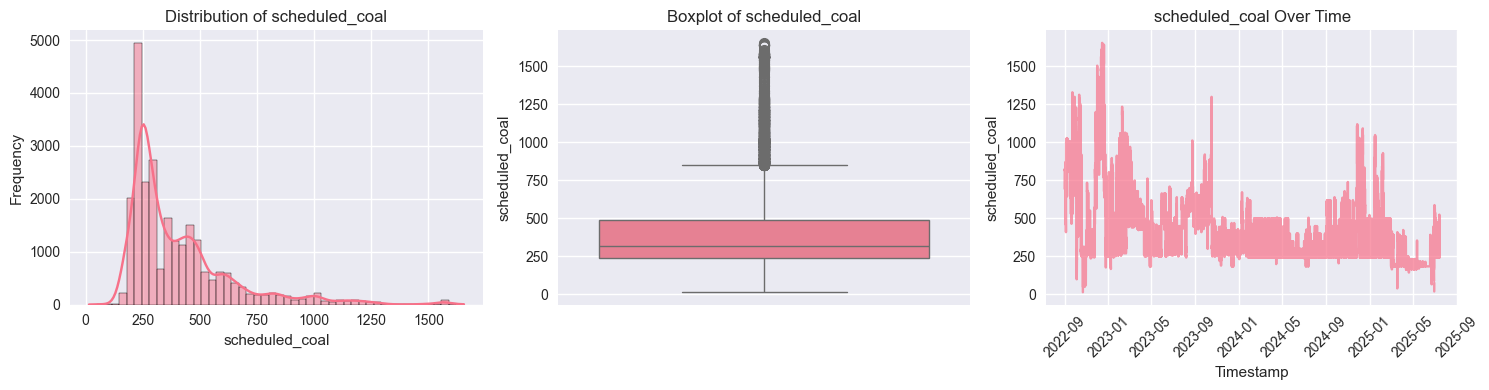


ANALYSIS FOR: scheduled_combined_cycle
count    26266.000000
mean      4206.297957
std       2994.971911
min        302.900000
25%       1981.137500
50%       3319.712500
75%       5689.350000
max      17054.625000
Name: scheduled_combined_cycle, dtype: float64

Additional Stats:
Skewness: 1.315
Kurtosis: 1.517
Missing values: 38
Zero values: 0 (0.00%)


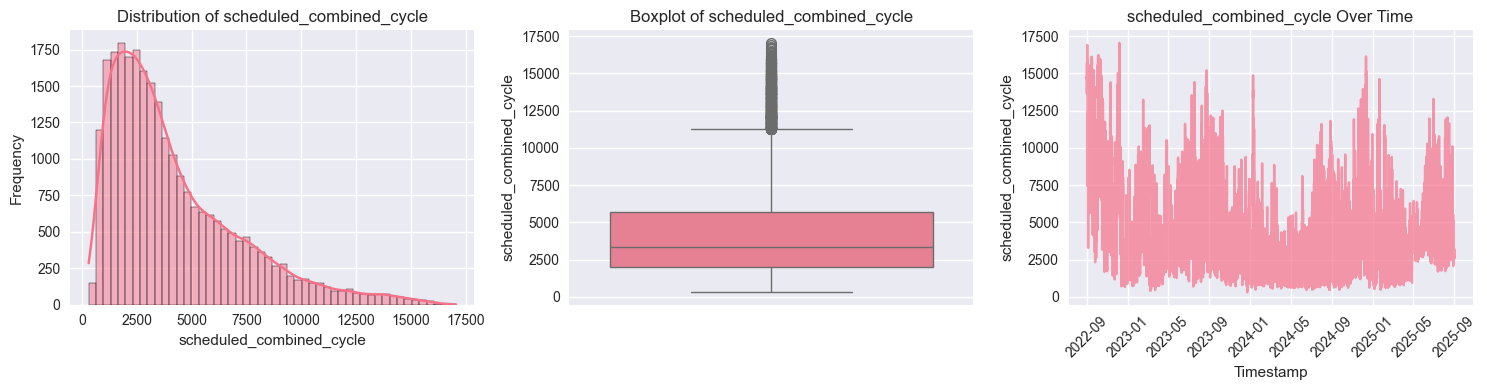


ANALYSIS FOR: scheduled_wind
count    26266.000000
mean      6879.659566
std       4083.082989
min        301.125000
25%       3602.518750
50%       6103.775000
75%       9496.906250
max      21271.000000
Name: scheduled_wind, dtype: float64

Additional Stats:
Skewness: 0.720
Kurtosis: -0.134
Missing values: 38
Zero values: 0 (0.00%)


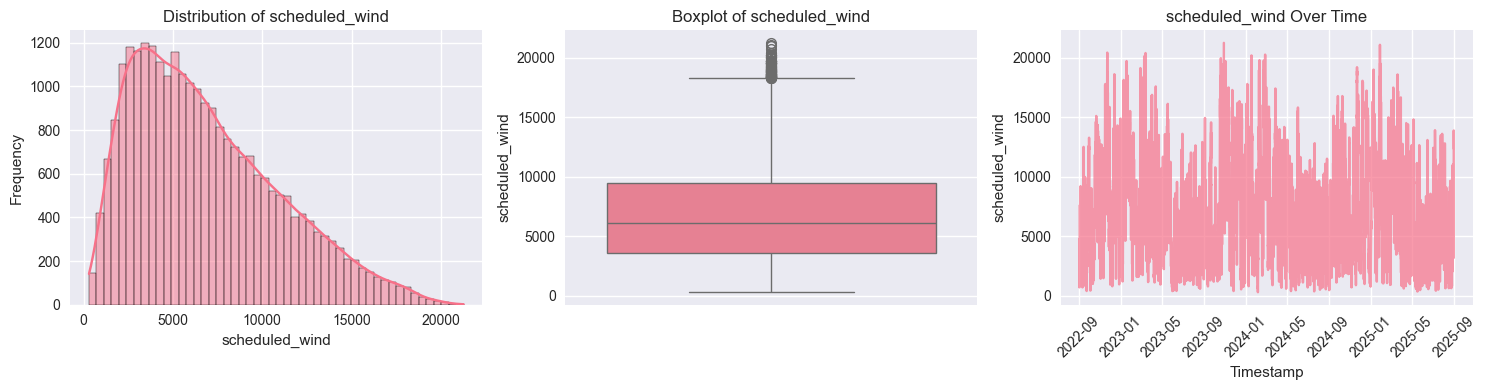


ANALYSIS FOR: scheduled_hydraulic
count    26266.000000
mean      3012.985097
std       1997.575420
min        148.125000
25%       1298.737500
50%       2624.050000
75%       4355.081250
max       9393.675000
Name: scheduled_hydraulic, dtype: float64

Additional Stats:
Skewness: 0.688
Kurtosis: -0.411
Missing values: 38
Zero values: 0 (0.00%)


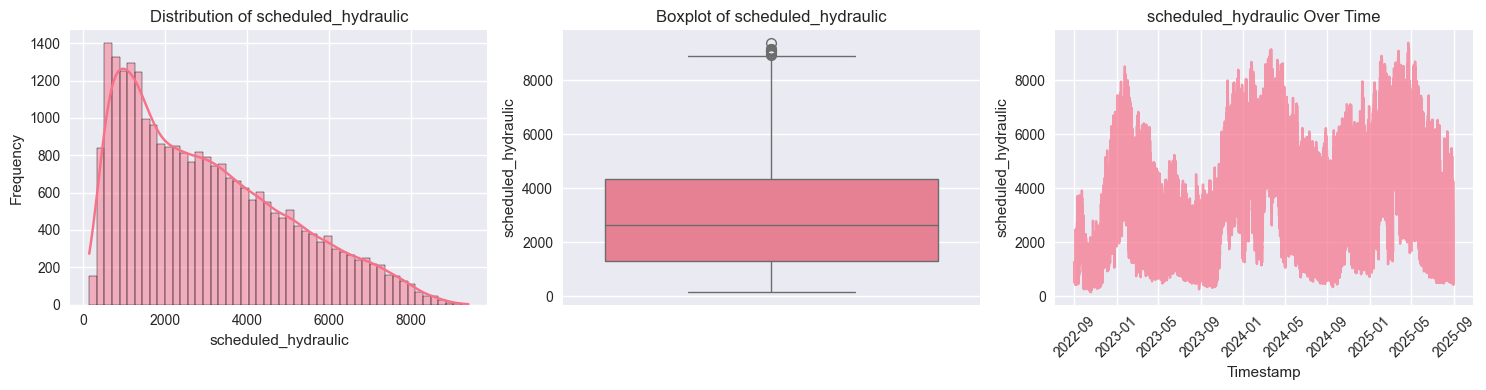


ANALYSIS FOR: scheduled_total_import
count    26178.000000
mean      1911.264616
std       1176.420914
min          0.200000
25%        888.025000
50%       1824.650000
75%       2808.000000
max       8100.325000
Name: scheduled_total_import, dtype: float64

Additional Stats:
Skewness: 0.365
Kurtosis: -0.538
Missing values: 126
Zero values: 0 (0.00%)


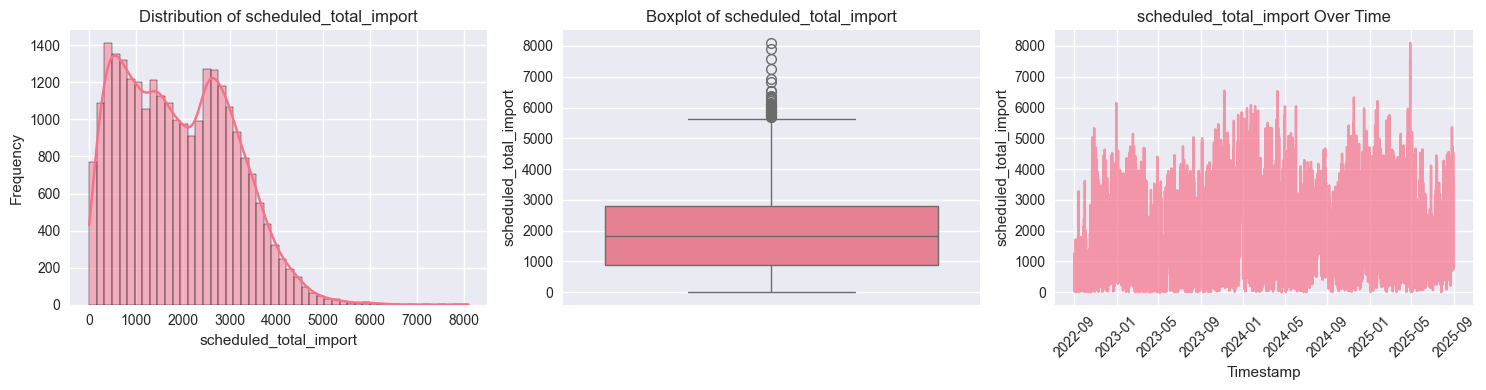


ANALYSIS FOR: scheduled_nuclear
count    26266.000000
mean      6083.731763
std       1073.778279
min        142.000000
25%       5095.000000
50%       6499.400000
75%       6945.900000
max      12101.400000
Name: scheduled_nuclear, dtype: float64

Additional Stats:
Skewness: -1.224
Kurtosis: 1.839
Missing values: 38
Zero values: 0 (0.00%)


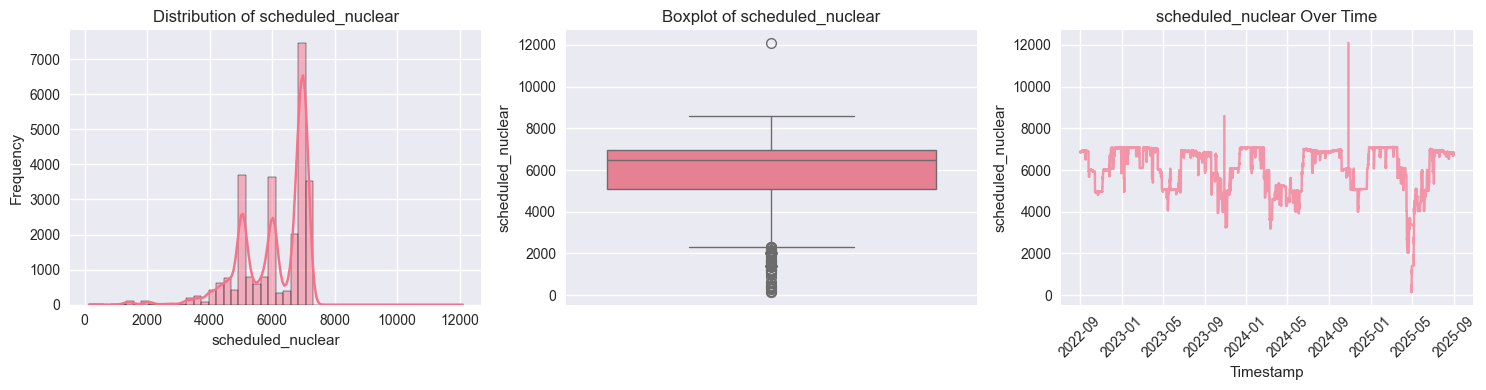


ANALYSIS FOR: scheduled_solar_pv
count    25521.000000
mean      4893.826097
std       6054.772868
min          0.025000
25%          3.600000
50%        705.100000
75%      10073.375000
max      22889.516000
Name: scheduled_solar_pv, dtype: float64

Additional Stats:
Skewness: 0.858
Kurtosis: -0.668
Missing values: 783
Zero values: 0 (0.00%)


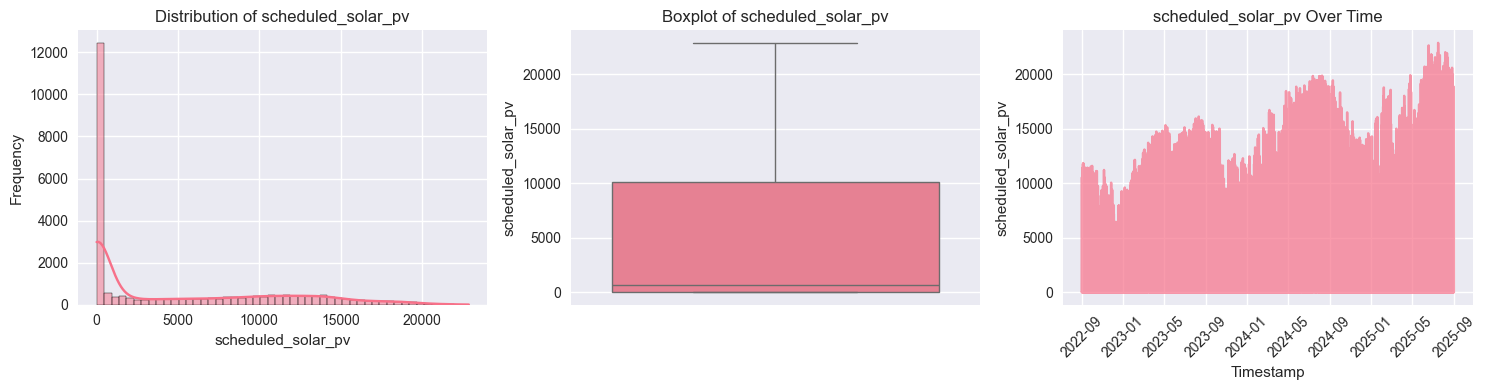


ANALYSIS FOR: actual_coal_generation
count    26302.000000
mean       390.836749
std        247.173132
min          0.000000
25%        248.916667
50%        308.083333
75%        490.895833
max       1576.250000
Name: actual_coal_generation, dtype: float64

Additional Stats:
Skewness: 1.541
Kurtosis: 3.526
Missing values: 2
Zero values: 1472 (5.60%)


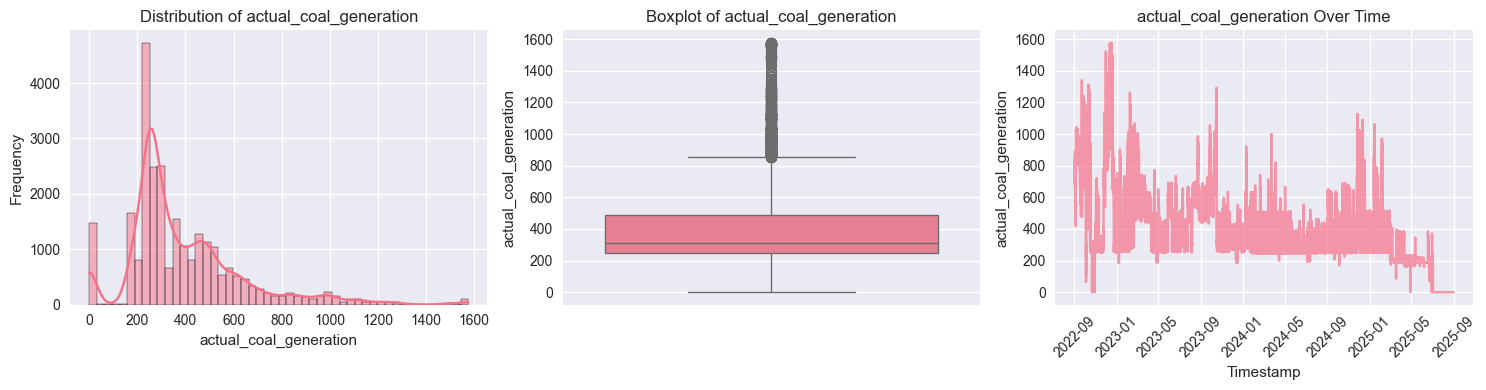


ANALYSIS FOR: actual_combined_cycle_generation
count    26221.000000
mean      5102.684035
std       3036.824465
min        672.666667
25%       2833.916667
50%       4253.916667
75%       6661.416667
max      18216.250000
Name: actual_combined_cycle_generation, dtype: float64

Additional Stats:
Skewness: 1.242
Kurtosis: 1.310
Missing values: 83
Zero values: 0 (0.00%)


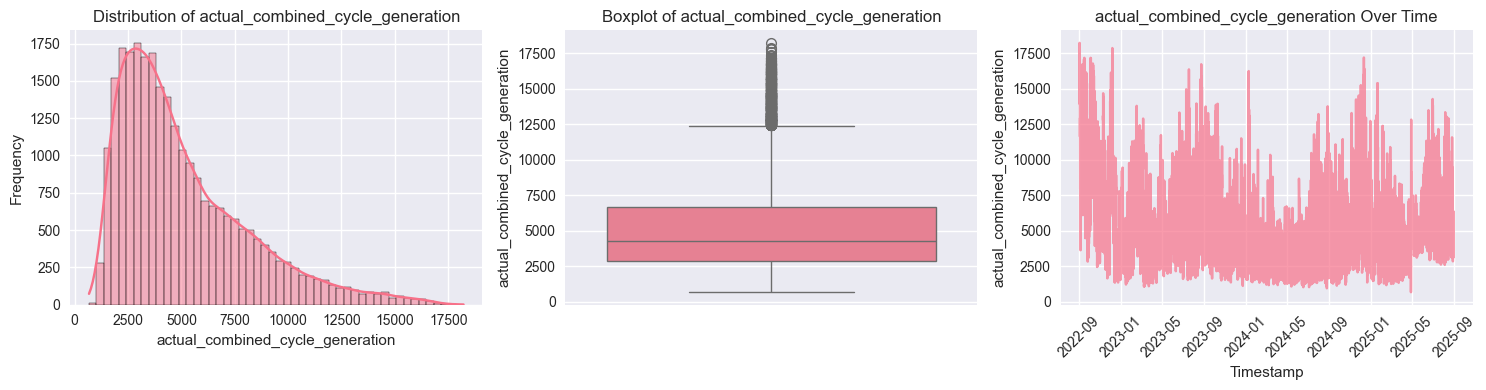


ANALYSIS FOR: actual_wind_generation
count    26221.000000
mean      6885.146076
std       4007.116740
min         80.083333
25%       3669.333333
50%       6179.166667
75%       9461.083333
max      20908.166667
Name: actual_wind_generation, dtype: float64

Additional Stats:
Skewness: 0.689
Kurtosis: -0.178
Missing values: 83
Zero values: 0 (0.00%)


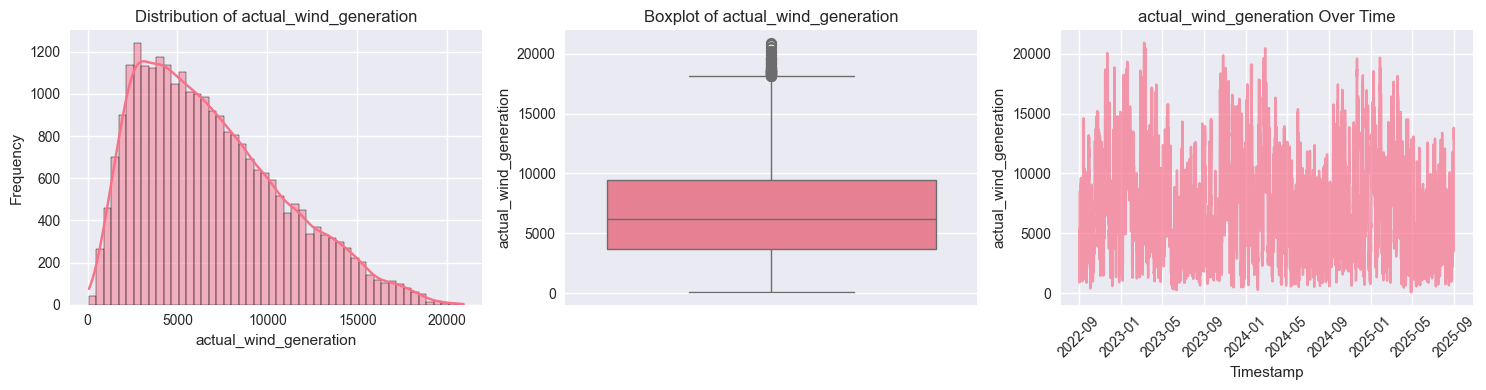


ANALYSIS FOR: actual_hydraulic_generation
count    26221.000000
mean      3109.744004
std       3082.350067
min      -3690.166667
25%        832.166667
50%       2932.500000
75%       5310.750000
max      11695.916667
Name: actual_hydraulic_generation, dtype: float64

Additional Stats:
Skewness: 0.199
Kurtosis: -0.615
Missing values: 83
Zero values: 0 (0.00%)
Negative values: 4478 (17.02%)


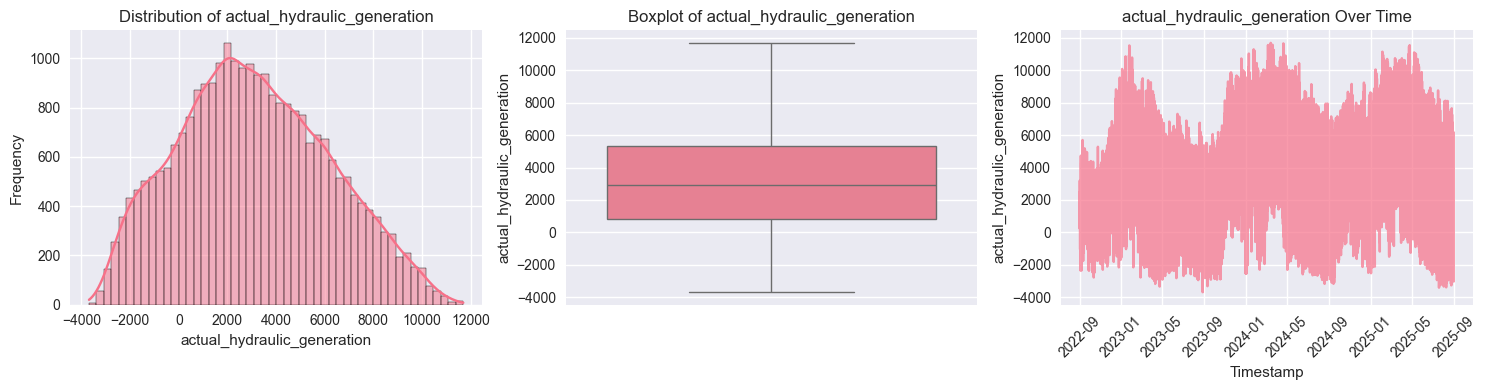


ANALYSIS FOR: actual_nuclear_generation
count    26221.000000
mean      6093.051645
std       1095.668374
min          0.000000
25%       5106.000000
50%       6490.833333
75%       6987.416667
max       7140.416667
Name: actual_nuclear_generation, dtype: float64

Additional Stats:
Skewness: -1.361
Kurtosis: 2.678
Missing values: 83
Zero values: 32 (0.12%)


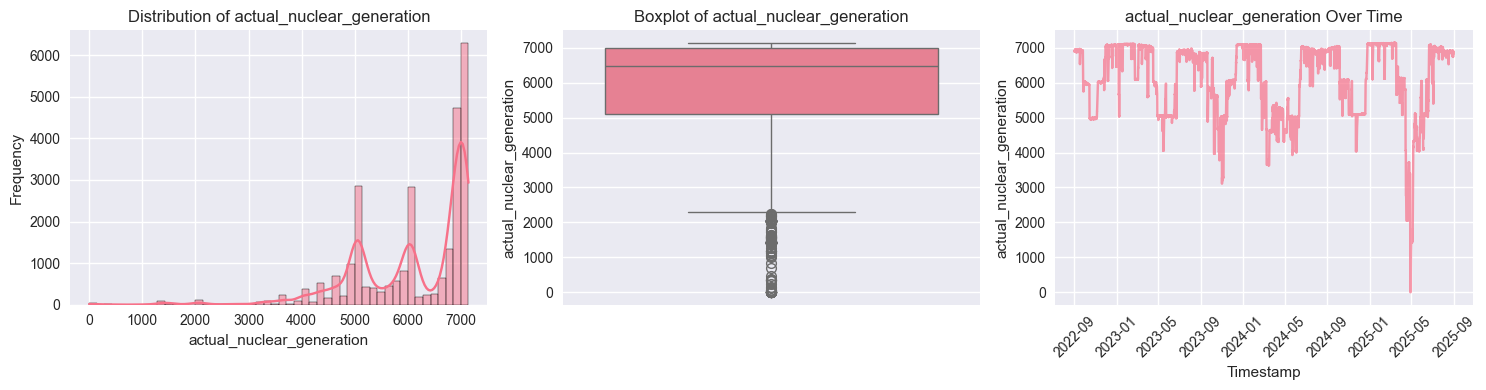


ANALYSIS FOR: actual_solar_pv_generation
count    26221.000000
mean      4685.597373
std       6003.637684
min          0.000000
25%         30.166667
50%        325.333333
75%       9678.750000
max      23220.916667
Name: actual_solar_pv_generation, dtype: float64

Additional Stats:
Skewness: 0.947
Kurtosis: -0.484
Missing values: 83
Zero values: 67 (0.25%)


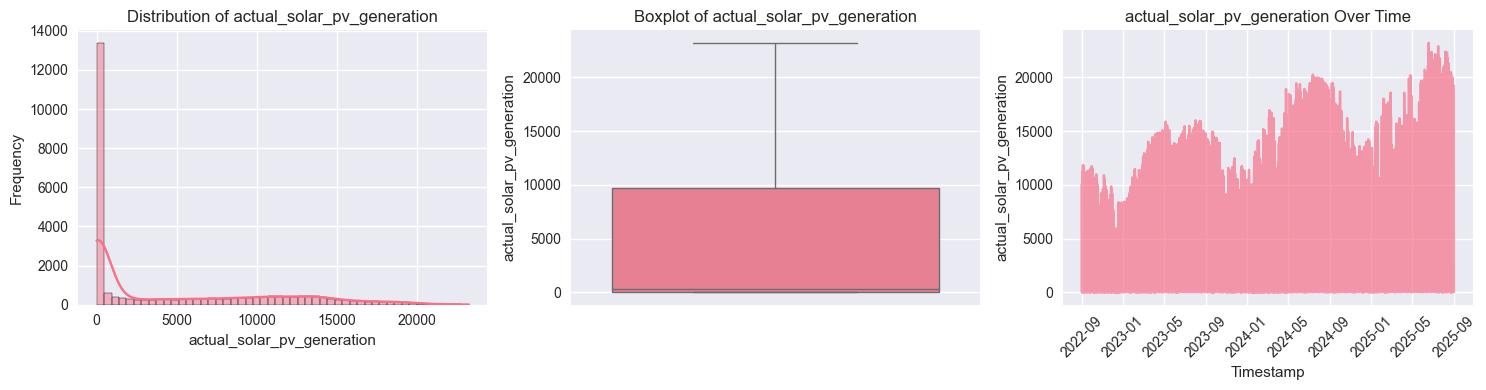


CORRELATION WITH TARGET VARIABLE (spot_price_spain)

Top variables correlated with spot_price_spain:
actual_combined_cycle_generation    | Correlation:   0.751 | Absolute:   0.751
scheduled_combined_cycle            | Correlation:   0.749 | Absolute:   0.749
scheduled_coal                      | Correlation:   0.470 | Absolute:   0.470
actual_coal_generation              | Correlation:   0.438 | Absolute:   0.438
scheduled_solar_pv                  | Correlation:  -0.397 | Absolute:   0.397
actual_solar_pv_generation          | Correlation:  -0.393 | Absolute:   0.393
dam_allocated_energy_spain          | Correlation:  -0.355 | Absolute:   0.355
actual_hydraulic_generation         | Correlation:   0.349 | Absolute:   0.349
scheduled_nuclear                   | Correlation:   0.305 | Absolute:   0.305
actual_nuclear_generation           | Correlation:   0.305 | Absolute:   0.305
scheduled_demand                    | Correlation:   0.296 | Absolute:   0.296
actual_national_demand       

In [70]:
# ---------------------------
# Basic stats & distributions for the rest of the variables 
# ---------------------------
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
all_variables = [
    'timestamp', 'scheduled_demand', 'actual_national_demand', 
    'dam_allocated_energy_spain', 'scheduled_coal', 'scheduled_combined_cycle',
    'scheduled_wind', 'scheduled_hydraulic', 'scheduled_total_import',
    'scheduled_nuclear', 'scheduled_solar_pv', 'actual_coal_generation',
    'actual_combined_cycle_generation', 'actual_wind_generation',
    'actual_hydraulic_generation', 'actual_nuclear_generation',
    'actual_solar_pv_generation', 'hour', 'day_of_week', 'month', 'spot_price_spain'
]

# numerical analysis
numerical_variables_sans_target = [var for var in all_variables if var not in ['timestamp','hour', 'day_of_week', 'month','spot_price_spain']]

for var in numerical_variables_sans_target:
    print(f"\n{'='*60}")
    print(f"ANALYSIS FOR: {var}")
    print(f"{'='*60}")
    
    # Basic
    print(Dataset[var].describe())
    
    # Additional
    print(f"\nAdditional Stats:")
    print(f"Skewness: {Dataset[var].skew():.3f}")
    print(f"Kurtosis: {Dataset[var].kurtosis():.3f}")
    print(f"Missing values: {Dataset[var].isnull().sum()}")
    print(f"Zero values: {(Dataset[var] == 0).sum()} ({(Dataset[var] == 0).mean()*100:.2f}%)")
    if Dataset[var].min() < 0:
        print(f"Negative values: {(Dataset[var] < 0).sum()} ({(Dataset[var] < 0).mean()*100:.2f}%)")
        
    
    plt.figure(figsize=(15, 4))
    
    # Distribution plot
    plt.subplot(1, 3, 1)
    sns.histplot(Dataset[var], bins=50, kde=True)
    plt.title(f'Distribution of {var}')
    plt.xlabel(var)
    plt.ylabel('Frequency')
    
    # Box plot
    plt.subplot(1, 3, 2)
    sns.boxplot(y=Dataset[var])
    plt.title(f'Boxplot of {var}')
    plt.ylabel(var)
    
    # Time series 
    plt.subplot(1, 3, 3)
    plt.plot(Dataset['timestamp'], Dataset[var], alpha=0.7)
    plt.title(f'{var} Over Time')
    plt.xlabel('Timestamp')
    plt.ylabel(var)
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

# Correlation analysis with target variable
print("\n" + "="*80)
print("CORRELATION WITH TARGET VARIABLE (spot_price_spain)")
print("="*80)

# Calculate correlations
correlations = []
for var in numerical_variables_sans_target:
        corr = Dataset[var].corr(Dataset['spot_price_spain'])
        correlations.append((var, corr, abs(corr)))

# Sort by absolute correlation
correlations.sort(key=lambda x: x[2], reverse=True)

print("\nTop variables correlated with spot_price_spain:")
for var, corr, abs_corr in correlations[:15]:
    print(f"{var:35} | Correlation: {corr:7.3f} | Absolute: {abs_corr:7.3f}")

print("\nBottom variables correlated with spot_price_spain:")
for var, corr, abs_corr in correlations[-10:]:
    print(f"{var:35} | Correlation: {corr:7.3f} | Absolute: {abs_corr:7.3f}")

## **Missing Values Problem**

- **scheduled_coal:** 1,224 missing values (4.65% )  
- **scheduled_solar_pv:** 783 missing values (2.98%)  
- **actual_national_demand:** 83 missing values  
- **Other variables:** 2–126 missing values  


## **Anomalies**

- **scheduled_demand:** 35 zeros + 2 missing →    
- **actual_coal_generation:** 1,472 zeros _(5.6%)_
- **actual_nuclear_generation:** 32 zeros, unusual 
- **scheduled_demand min = 0** 


## Price Drivers
- **Combined cycle:** +0.75  
- **Coal:** +0.47  

## Renewables Push Prices Down 
- **Solar PV:** -0.39  
- **Wind:** -0.24  

## Nuclear  
- Operates as base-load generation  
- Acts as a price-taker, even during high-price periods  

## Demand  
- Moderate correlation with price (**0.28–0.30**)  
- Indicates relatively inelastic electricity demand  

### Key Price Drivers
- **Combined cycle**: primary price setter, strong positive correlation  
- **Coal**: influences price when operating at the margin  
- **Renewables**: higher penetration consistently depresses prices  



Original dataset size: 26304
Clean dataset size (without price outliers): 26253
Price outliers removed: 51 (0.19%)


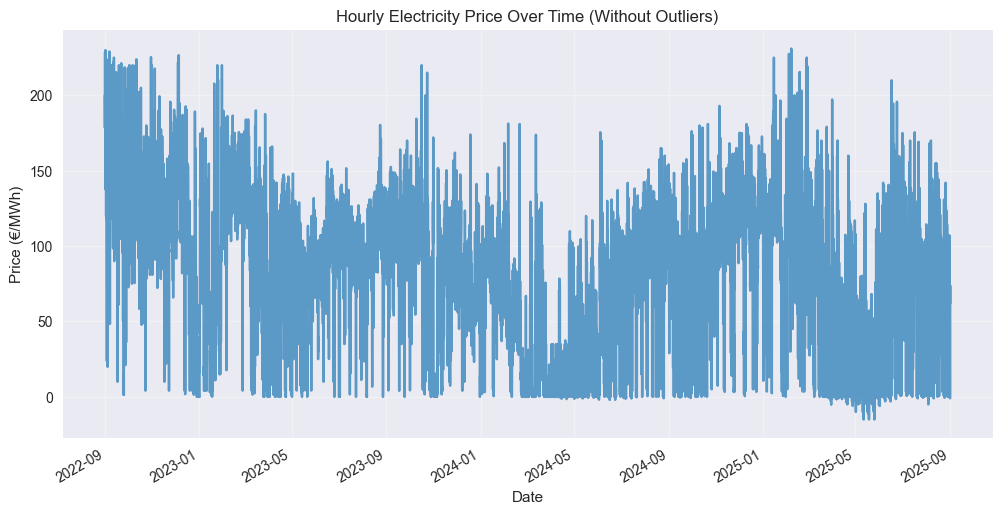

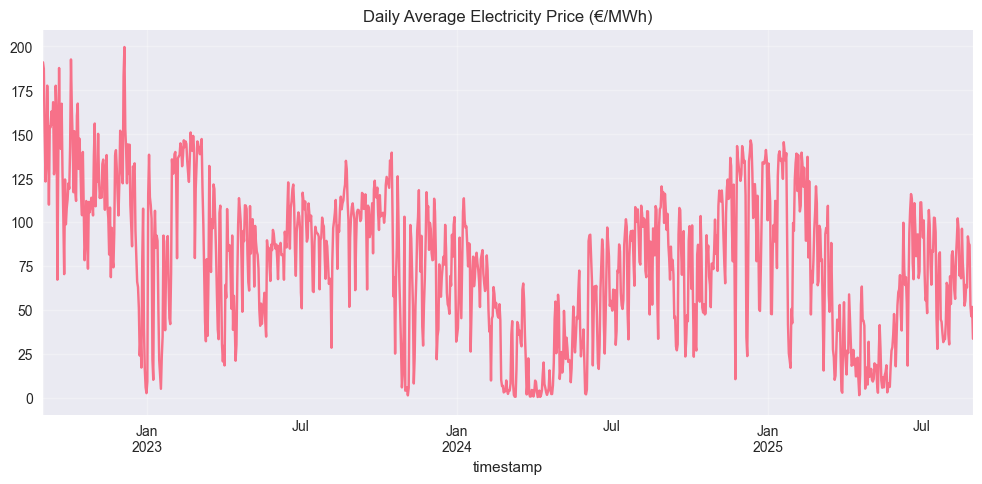

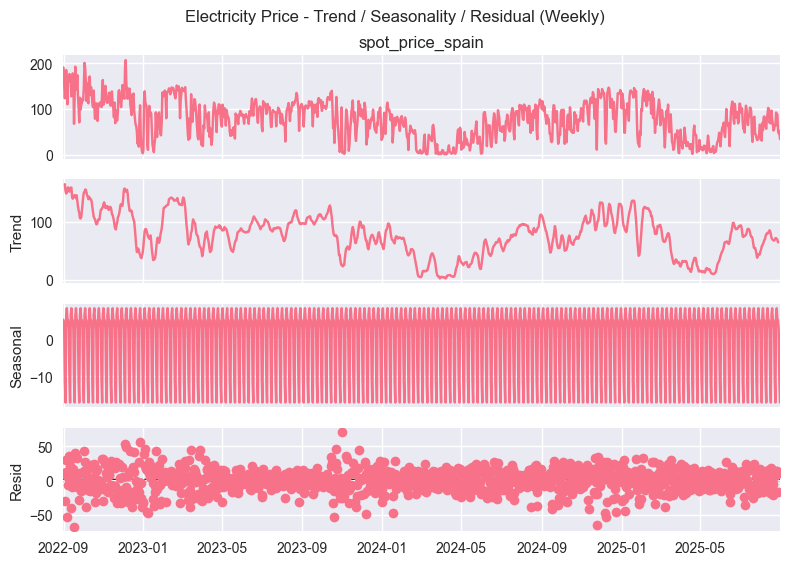

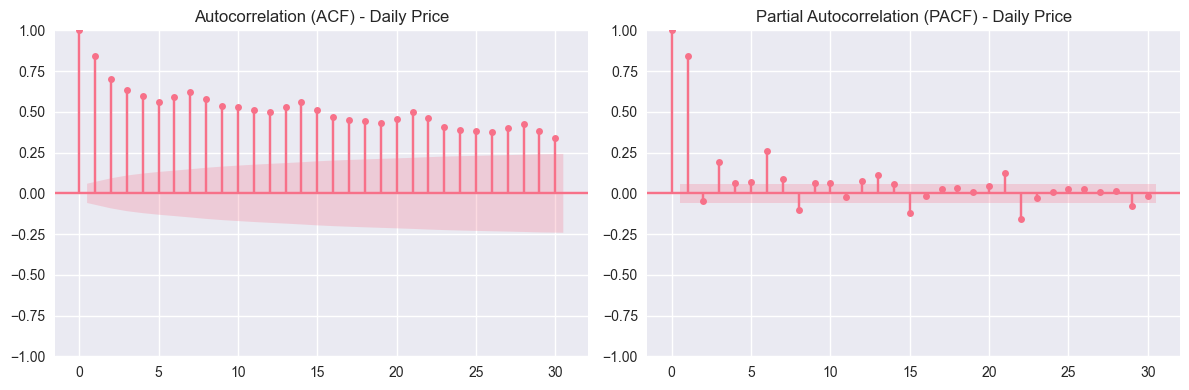

NA timestamp: 0 Duplicates: 0
Missing hours: 0


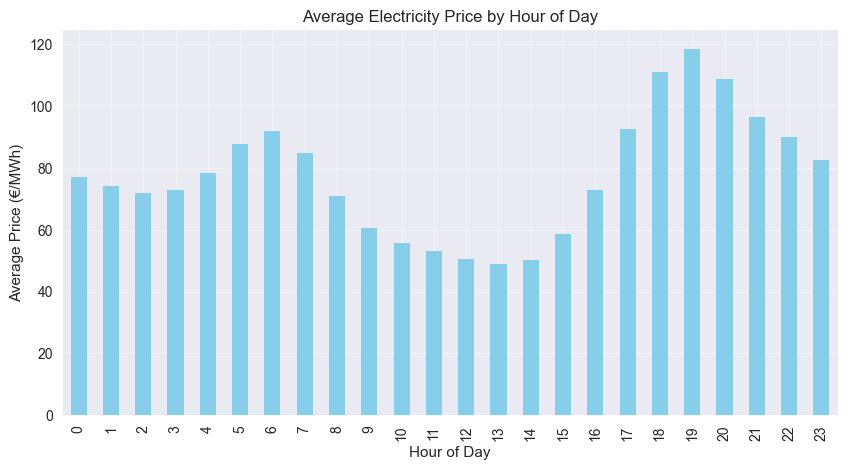

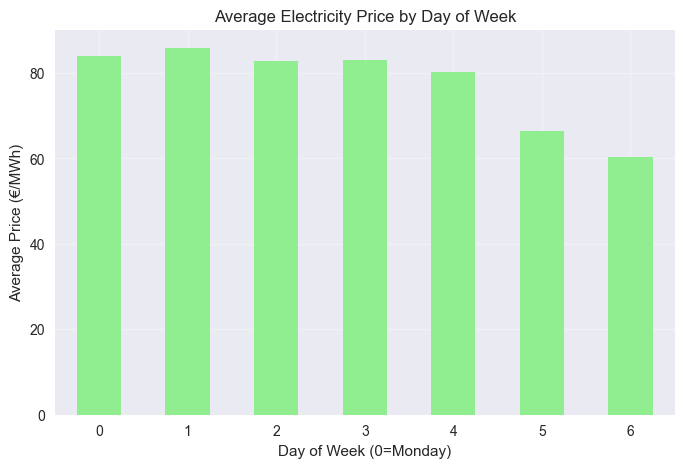

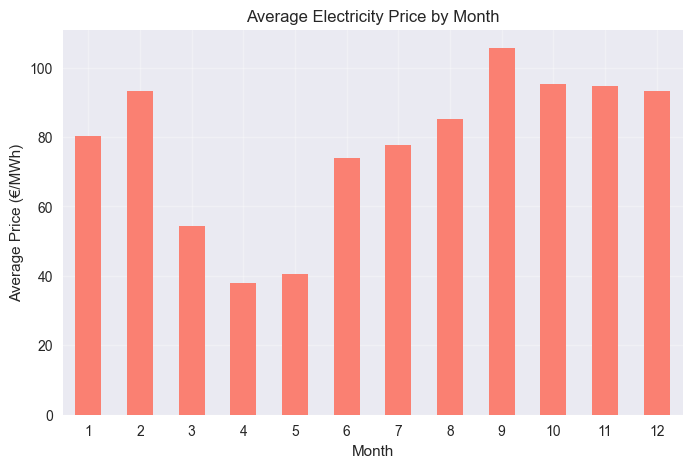

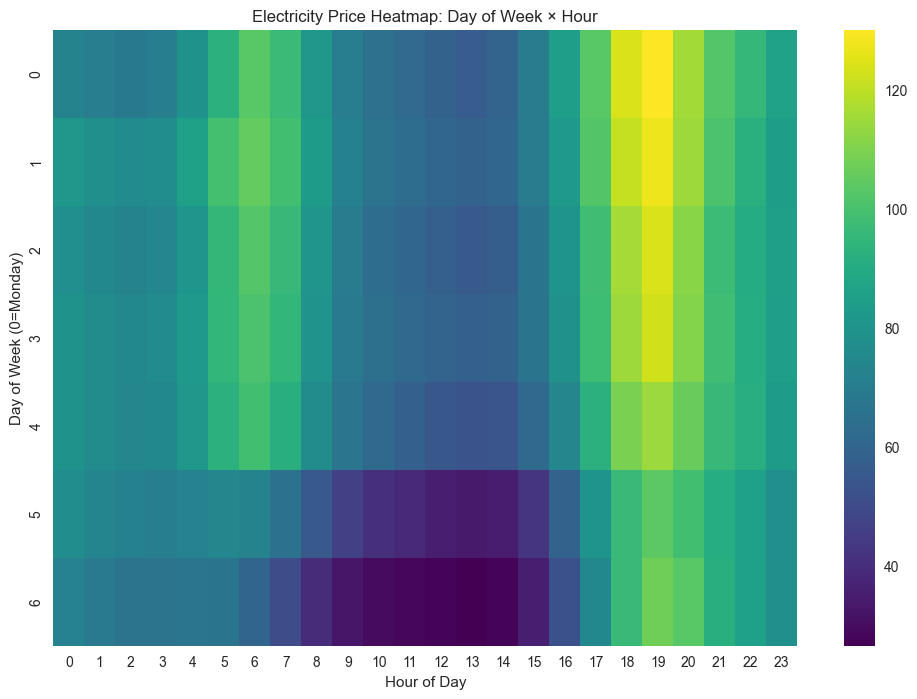

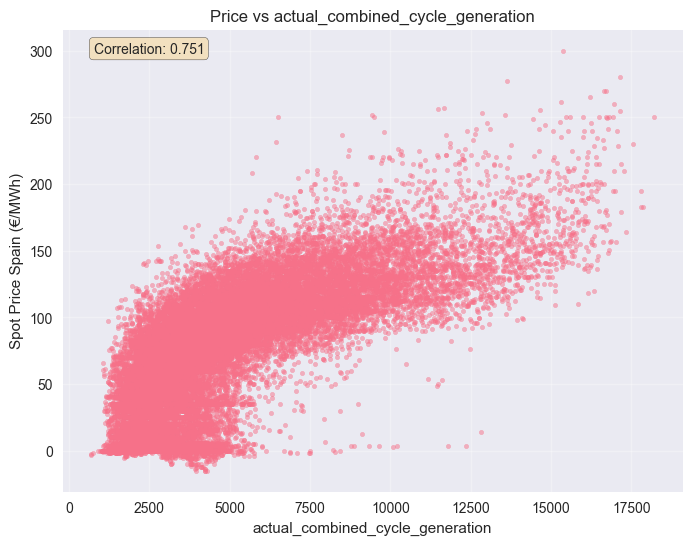

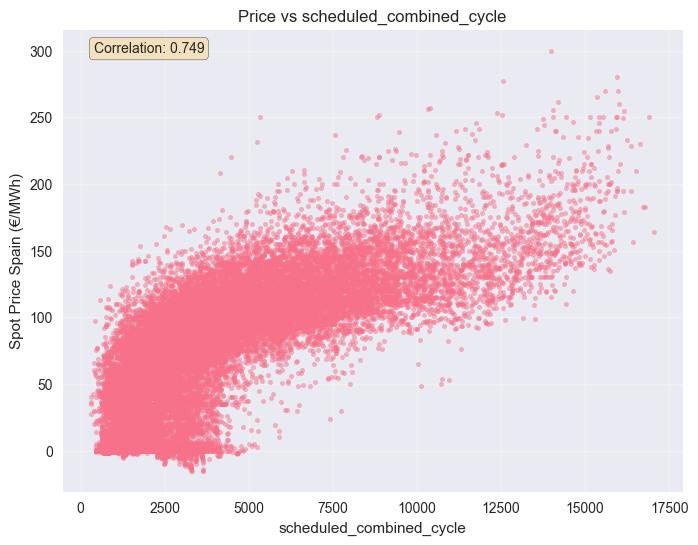

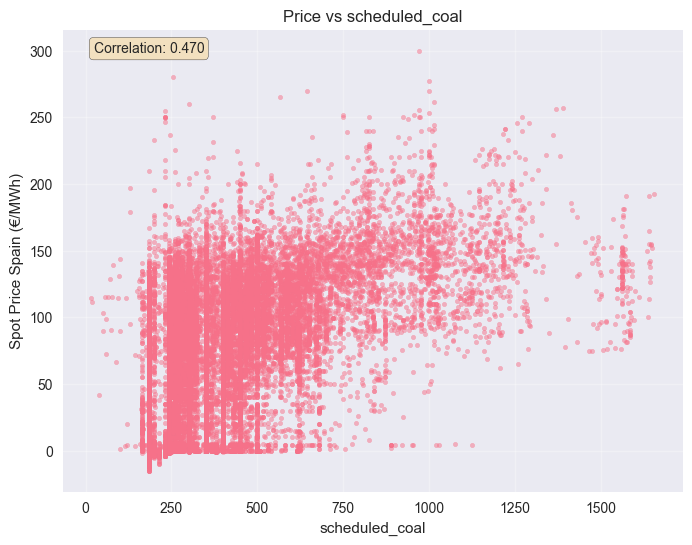

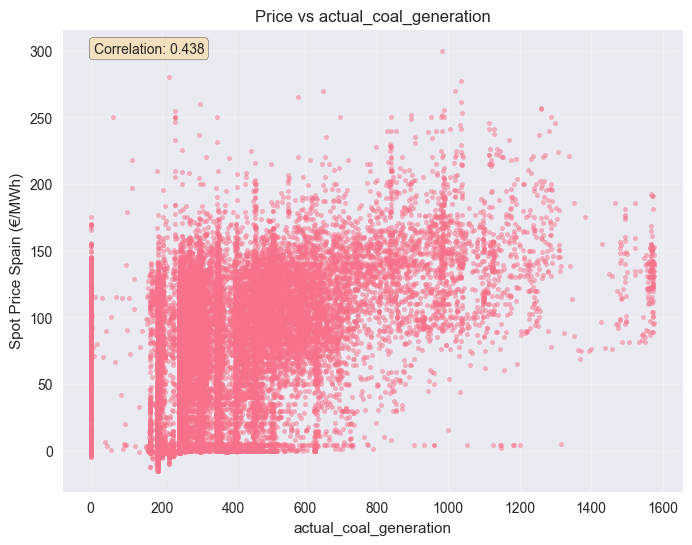

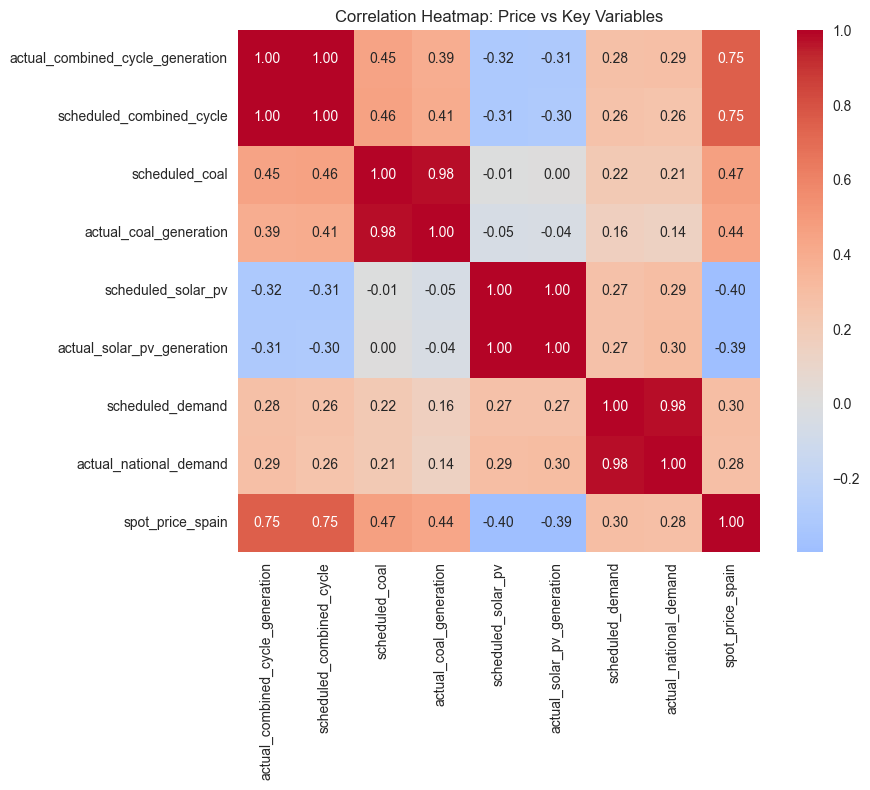

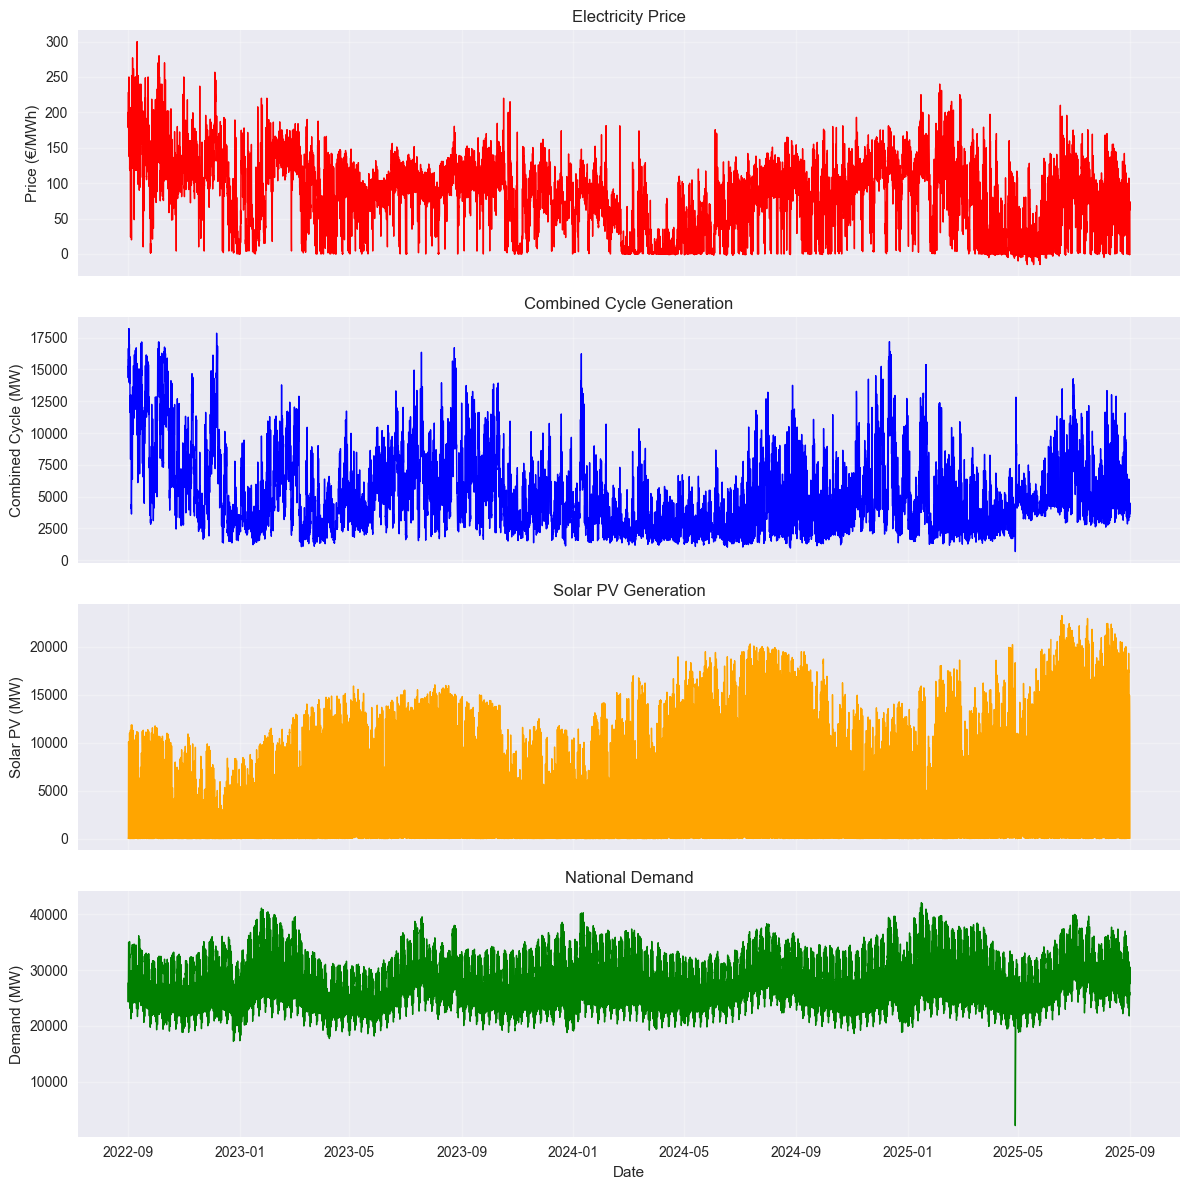

In [ ]:
# ---------------------------
# Outlier filter (IQR) for EDA plots only  
# Outliers removed only for visualization purposes, the original dataset is not modified

# ---------------------------
def remove_outliers_iqr(df, col):
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    return df[(df[col] >= lower) & (df[col] <= upper)]

# target variable clean visualization
clean_price = remove_outliers_iqr(Dataset, 'spot_price_spain').copy()
clean_price = clean_price.set_index('timestamp').sort_index()

print(f"Original dataset size: {len(Dataset)}")
print(f"Clean dataset size (without price outliers): {len(clean_price)}")
print(f"Price outliers removed: {len(Dataset) - len(clean_price)} ({(len(Dataset) - len(clean_price)) / len(Dataset) * 100:.2f}%)")

# Time series plots (hourly, daily mean)
plt.figure(figsize=(12,6))
clean_price['spot_price_spain'].plot(color='tab:blue', alpha=0.7)
plt.title('Hourly Electricity Price Over Time (Without Outliers)')
plt.xlabel('Date'); plt.ylabel('Price (€/MWh)')
plt.grid(True, alpha=0.3)
plt.show()

# Daily average price
daily_price = clean_price['spot_price_spain'].resample('D').mean().dropna()
daily_price.plot(figsize=(12,5), title='Daily Average Electricity Price (€/MWh)')
plt.grid(True, alpha=0.3)
plt.show()

# Seasonal decomposition + ACF/PACF
# Use original data for decomposition to preserve seasonality
daily_original = Dataset.set_index('timestamp')['spot_price_spain'].resample('D').mean().dropna()
decomp = seasonal_decompose(daily_original, period=7, model='additive')  # Weekly
decomp.plot()
plt.suptitle('Electricity Price - Trend / Seasonality / Residual (Weekly)', y=1.02)
plt.show()

# ACF and PACF plots
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plot_acf(daily_original, lags=30, ax=plt.gca())
plt.title('Autocorrelation (ACF) - Daily Price')

plt.subplot(1,2,2)
plot_pacf(daily_original, lags=30, method='ywm', ax=plt.gca())
plt.title('Partial Autocorrelation (PACF) - Daily Price')

plt.tight_layout()
plt.show()


# Data quality: gaps & duplicates

Dataset_indexed = Dataset.set_index('timestamp').sort_index()

missing_dt = Dataset['timestamp'].isna().sum()
dup_dt = Dataset.duplicated('timestamp').sum()
print("NA timestamp:", missing_dt, "Duplicates:", dup_dt)

# Check for missing hours

full_idx = pd.date_range(Dataset_indexed.index.min(),
                         Dataset_indexed.index.max(), freq='H')
gap_idx = full_idx.difference(Dataset_indexed.index)
print("Missing hours:", len(gap_idx))

if len(gap_idx) > 0:
    print("First 10 missing timestamps:")
    print(gap_idx[:10])


# 1Hour/Month profiles + heatmap

prof = Dataset_indexed.copy()
prof['Hour'] = prof.index.hour
prof['DOW'] = prof.index.dayofweek  # 0=Mon ... 6=Sun
prof['Month'] = prof.index.month

# Hourly profile
hour_profile = prof.groupby('Hour')['spot_price_spain'].mean()
plt.figure(figsize=(10,5))
hour_profile.plot(kind='bar', color='skyblue')
plt.title('Average Electricity Price by Hour of Day')
plt.xlabel('Hour of Day'); plt.ylabel('Average Price (€/MWh)')
plt.grid(True, alpha=0.3)
plt.show()

# Day of week profile
dow_profile = prof.groupby('DOW')['spot_price_spain'].mean()
plt.figure(figsize=(8,5))
dow_profile.plot(kind='bar', color='lightgreen')
plt.title('Average Electricity Price by Day of Week')
plt.xlabel('Day of Week (0=Monday)'); plt.ylabel('Average Price (€/MWh)')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3)
plt.show()

# Monthly profile
month_profile = prof.groupby('Month')['spot_price_spain'].mean()
plt.figure(figsize=(8,5))
month_profile.plot(kind='bar', color='salmon')
plt.title('Average Electricity Price by Month')
plt.xlabel('Month'); plt.ylabel('Average Price (€/MWh)')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3)
plt.show()

# Heatmap: Day of Week vs Hour
heatmap_data = prof.groupby(['DOW', 'Hour'])['spot_price_spain'].mean().unstack()
plt.figure(figsize=(12,8))
sns.heatmap(heatmap_data, cmap='viridis', annot=False)
plt.title('Electricity Price Heatmap: Day of Week × Hour')
plt.xlabel('Hour of Day'); plt.ylabel('Day of Week (0=Monday)')
plt.show()




# ---------------------------
# Price vs Key Variables Analysis
# ---------------------------
# Top correlated variables
top_correlated_vars = ['actual_combined_cycle_generation', 'scheduled_combined_cycle', 
                       'scheduled_coal', 'actual_coal_generation', 'scheduled_solar_pv',
                       'actual_solar_pv_generation', 'scheduled_demand', 'actual_national_demand']


for var in top_correlated_vars[:4]:  # Plot first 4
    plt.figure(figsize=(8,6))
    plt.scatter(Dataset[var], Dataset['spot_price_spain'], alpha=0.5, s=10)
    plt.xlabel(var)
    plt.ylabel('Spot Price Spain (€/MWh)')
    plt.title(f'Price vs {var}')
    plt.grid(True, alpha=0.3)
    
   
    corr = Dataset[var].corr(Dataset['spot_price_spain'])
    plt.text(0.05, 0.95, f'Correlation: {corr:.3f}', 
             transform=plt.gca().transAxes, bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.8))
    plt.show()

# Correlation heatmap 
top_vars_heatmap = top_correlated_vars + ['spot_price_spain']
corr_matrix = Dataset[top_vars_heatmap].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Correlation Heatmap: Price vs Key Variables')
plt.tight_layout()
plt.show()

# Parallel time series: Price vs Top 3 variables
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

# Price
axes[0].plot(Dataset_indexed.index, Dataset_indexed['spot_price_spain'], color='red', linewidth=1)
axes[0].set_ylabel('Price (€/MWh)')
axes[0].set_title('Electricity Price')
axes[0].grid(True, alpha=0.3)

# Combined Cycle Generation
axes[1].plot(Dataset_indexed.index, Dataset_indexed['actual_combined_cycle_generation'], color='blue', linewidth=1)
axes[1].set_ylabel('Combined Cycle (MW)')
axes[1].set_title('Combined Cycle Generation')
axes[1].grid(True, alpha=0.3)

# Solar PV Generation
axes[2].plot(Dataset_indexed.index, Dataset_indexed['actual_solar_pv_generation'], color='orange', linewidth=1)
axes[2].set_ylabel('Solar PV (MW)')
axes[2].set_title('Solar PV Generation')
axes[2].grid(True, alpha=0.3)

# Demand
axes[3].plot(Dataset_indexed.index, Dataset_indexed['actual_national_demand'], color='green', linewidth=1)
axes[3].set_ylabel('Demand (MW)')
axes[3].set_title('National Demand')
axes[3].grid(True, alpha=0.3)
axes[3].set_xlabel('Date')

plt.tight_layout()
plt.show()






In [72]:

# ---------------------------
# Compare Scheduled vs Actual Generation
# ---------------------------
# For key generation types
comparison_vars = [
    ('scheduled_combined_cycle', 'actual_combined_cycle_generation'),
    ('scheduled_wind', 'actual_wind_generation'),
    ('scheduled_solar_pv', 'actual_solar_pv_generation'),
    ('scheduled_hydraulic', 'actual_hydraulic_generation')
]

for scheduled, actual in comparison_vars:
    #plt.figure(figsize=(12,5))
    #plt.plot(Dataset_indexed.index, Dataset_indexed[scheduled], label=f'Scheduled', alpha=0.7)
    #plt.plot(Dataset_indexed.index, Dataset_indexed[actual], label=f'Actual', alpha=0.7)
    #plt.title(f'Scheduled vs Actual: {scheduled.replace("scheduled_", "").title()}')
    #plt.ylabel('MW')
    #plt.legend()
    #plt.grid(True, alpha=0.3)
    #plt.show()
    #uncomment the above lines to see the plots, 
    
    # Calculate forecast error
    if scheduled in Dataset.columns and actual in Dataset.columns:
        error = Dataset[actual] - Dataset[scheduled]
        print(f"{scheduled} vs {actual}:")
        print(f"  Mean Error: {error.mean():.2f} MW")
        print(f"  Std Error: {error.std():.2f} MW")
        print(f"  Correlation: {Dataset[scheduled].corr(Dataset[actual]):.3f}\n")


scheduled_combined_cycle vs actual_combined_cycle_generation:
  Mean Error: 889.66 MW
  Std Error: 302.56 MW
  Correlation: 0.995

scheduled_wind vs actual_wind_generation:
  Mean Error: 18.57 MW
  Std Error: 590.67 MW
  Correlation: 0.990

scheduled_solar_pv vs actual_solar_pv_generation:
  Mean Error: -66.88 MW
  Std Error: 479.92 MW
  Correlation: 0.997

scheduled_hydraulic vs actual_hydraulic_generation:
  Mean Error: 92.96 MW
  Std Error: 1520.23 MW
  Correlation: 0.908



Hourly correlation matrix:
    scheduled_demand  scheduled_wind  scheduled_solar_pv  scheduled_hydraulic  \
0           0.245619       -0.543196           -0.054373            -0.331667   
1           0.262320       -0.547789           -0.025607            -0.357069   
2           0.267615       -0.556475           -0.030810            -0.357425   
3           0.263922       -0.564075           -0.052789            -0.357651   
4           0.278773       -0.563876            0.098060            -0.312674   
5           0.332052       -0.532432           -0.016440            -0.185478   
6           0.374347       -0.383873           -0.222151            -0.045579   
7           0.427224       -0.198400           -0.403397             0.149448   
8           0.451169       -0.109789           -0.446343             0.184010   
9           0.465394       -0.093593           -0.389986             0.111722   
10          0.463776       -0.100065           -0.336889             0.038278   
1

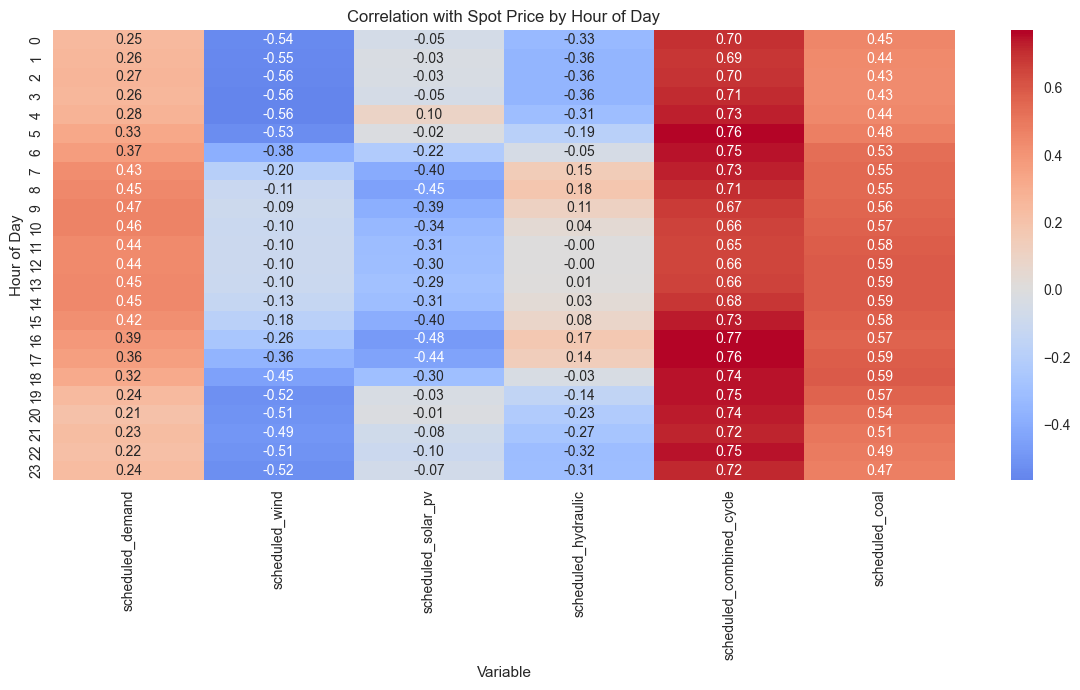

In [73]:
# Dataset_indexed = Dataset.set_index('timestamp').sort_index()

df = Dataset_indexed.copy()
df['hour'] = df.index.hour

# Candidate variables for correlation
vars_corr = [
    'scheduled_demand',
    'scheduled_wind',
    'scheduled_solar_pv',
    'scheduled_hydraulic',
    'scheduled_combined_cycle',
    'scheduled_coal'
]

# Time matrix: rows = hour, columns = variable
hourly_corr = pd.DataFrame(index=range(24), columns=vars_corr)

for h in range(24):
    subset = df[df['hour'] == h]
    for var in vars_corr:
        hourly_corr.loc[h, var] = subset[var].corr(subset['spot_price_spain'])

hourly_corr = hourly_corr.astype(float)

print("Hourly correlation matrix:")
print(hourly_corr)

# -------- HEATMAP -------- VERY USEFUL
plt.figure(figsize=(12, 7))
sns.heatmap(hourly_corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Correlation with Spot Price by Hour of Day")
plt.xlabel("Variable")
plt.ylabel("Hour of Day")
plt.tight_layout()
plt.show()


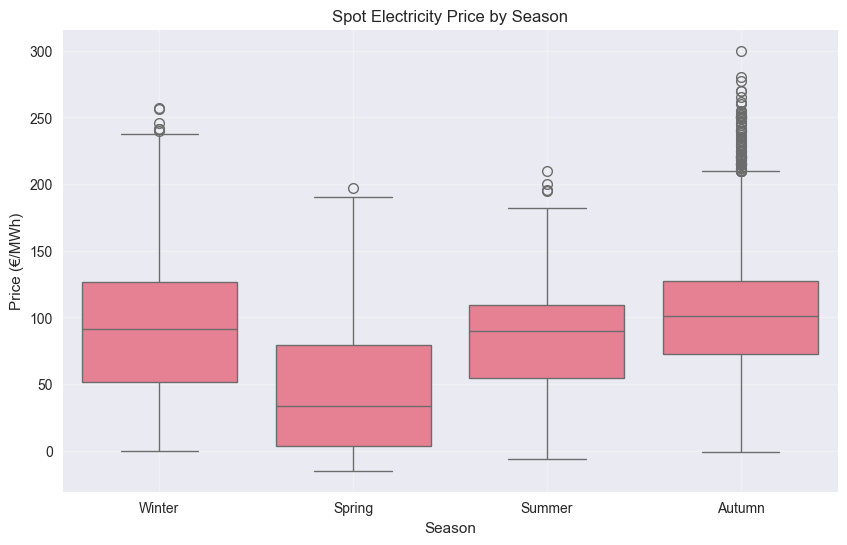

In [74]:
# Add season column
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

season_df = Dataset_indexed.copy()
season_df['Season'] = season_df.index.month.map(get_season)

plt.figure(figsize=(10,6))
sns.boxplot(x='Season', y='spot_price_spain', data=season_df,
            order=['Winter', 'Spring', 'Summer', 'Autumn'])
plt.title("Spot Electricity Price by Season")
plt.ylabel("Price (€/MWh)")
plt.grid(True, alpha=0.3)
plt.show()


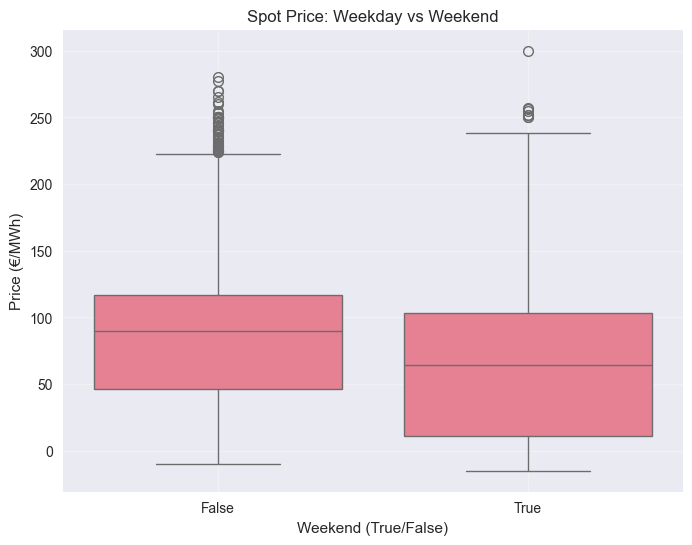

In [75]:
weekday_df = Dataset_indexed.copy()
weekday_df['is_weekend'] = weekday_df.index.dayofweek >= 5  # Saturday=5, Sunday=6

plt.figure(figsize=(8,6))
sns.boxplot(x='is_weekend', y='spot_price_spain', data=weekday_df)
plt.title('Spot Price: Weekday vs Weekend')
plt.xlabel('Weekend (True/False)')
plt.ylabel('Price (€/MWh)')
plt.grid(True, alpha=0.3)
plt.show()


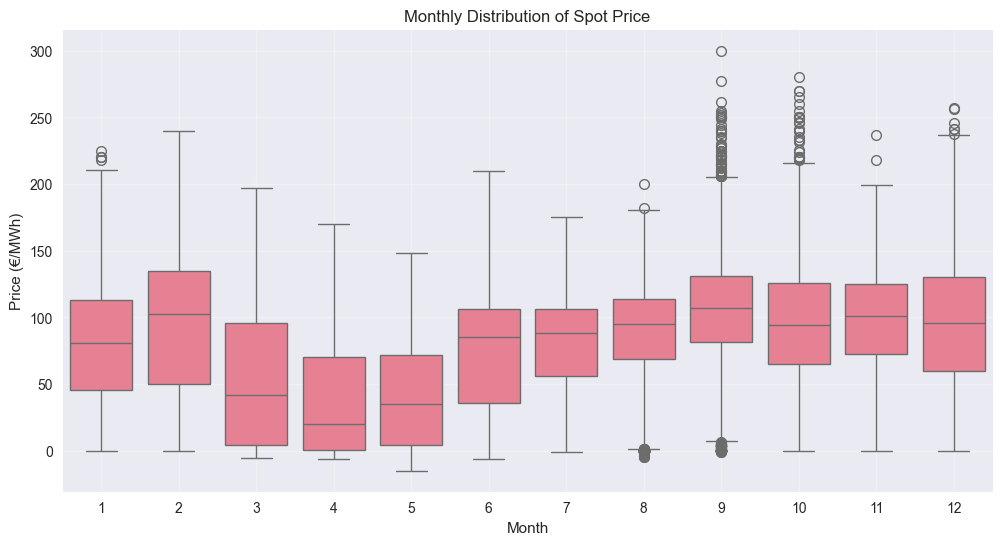

In [76]:
plt.figure(figsize=(12,6))
sns.boxplot(x=Dataset_indexed.index.month, y=Dataset_indexed['spot_price_spain'])
plt.title("Monthly Distribution of Spot Price")
plt.xlabel("Month")
plt.ylabel("Price (€/MWh)")
plt.grid(True, alpha=0.3)
plt.show()


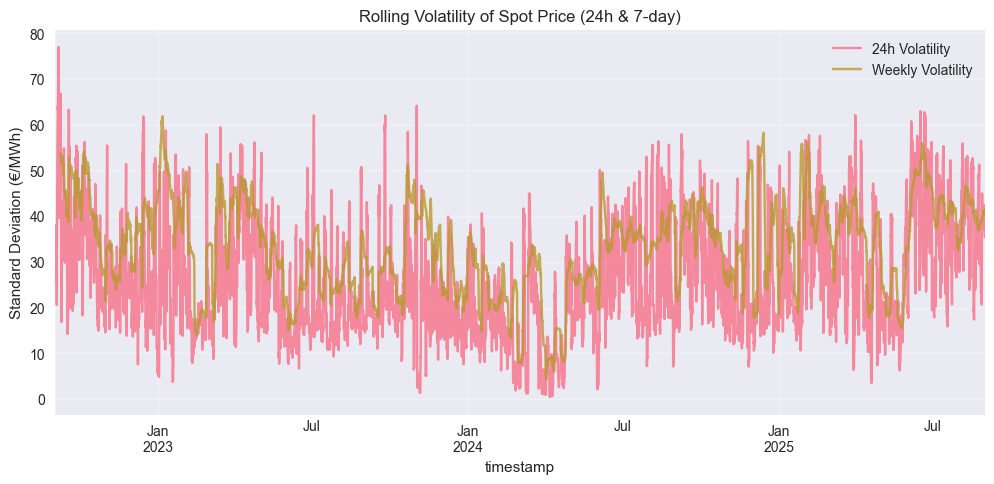

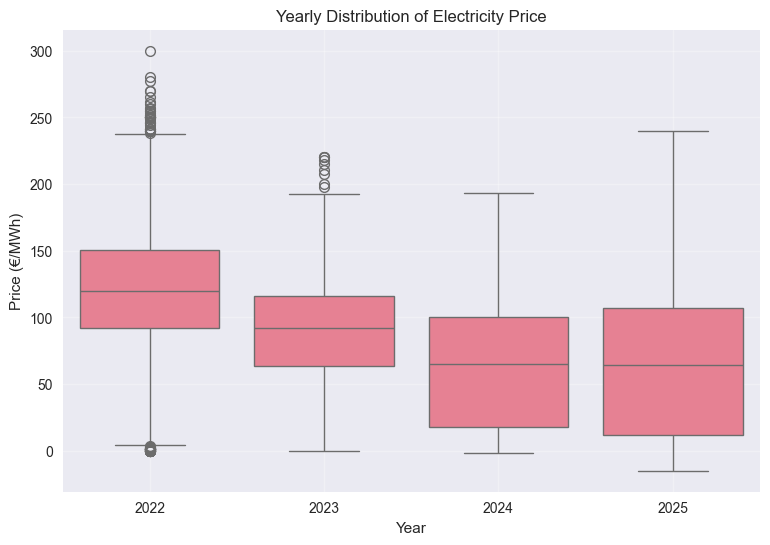

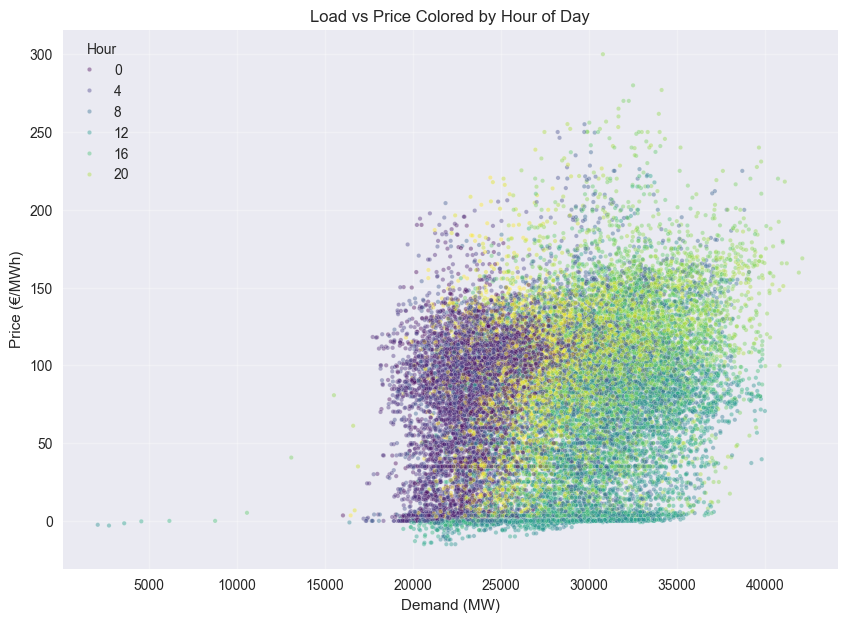

Spike count: 185
Spike %: 0.7033150851581509

Spikes by hour:
timestamp
4      2
5      7
6     18
7     16
8      2
9      1
10     1
11     1
12     1
13     1
14     1
15     1
16     4
17    14
18    38
19    43
20    17
21     7
22     8
23     2
Name: count, dtype: int64

Spikes by month:
timestamp
1      6
2     15
6      1
9     78
10    60
11     2
12    23
Name: count, dtype: int64


In [77]:
#other useful plots

price_ts = Dataset_indexed['spot_price_spain']

plt.figure(figsize=(12,5))
price_ts.rolling(24).std().plot(label='24h Volatility', alpha=0.8)
price_ts.rolling(168).std().plot(label='Weekly Volatility', alpha=0.8)
plt.title("Rolling Volatility of Spot Price (24h & 7-day)")
plt.ylabel("Standard Deviation (€/MWh)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


Dataset_indexed['Year'] = Dataset_indexed.index.year

plt.figure(figsize=(9,6))
sns.boxplot(x='Year', y='spot_price_spain', data=Dataset_indexed)
plt.title("Yearly Distribution of Electricity Price")
plt.ylabel("Price (€/MWh)")
plt.grid(True, alpha=0.3)
plt.show()



df_hp = Dataset_indexed.copy()
df_hp['Hour'] = df_hp.index.hour

plt.figure(figsize=(10,7))
sns.scatterplot(
    data=df_hp, x='actual_national_demand', y='spot_price_spain',
    hue='Hour', palette='viridis', alpha=0.4, s=10
)
plt.title("Load vs Price Colored by Hour of Day")
plt.xlabel("Demand (MW)")
plt.ylabel("Price (€/MWh)")
plt.grid(True, alpha=0.3)
plt.show()



spikes = Dataset_indexed[Dataset_indexed['spot_price_spain'] > 200]

print("Spike count:", len(spikes))
print("Spike %:", len(spikes)/len(Dataset_indexed)*100)

print("\nSpikes by hour:")
print(spikes.index.hour.value_counts().sort_index())

print("\nSpikes by month:")
print(spikes.index.month.value_counts().sort_index())



Dataset time range: 2022-08-31 22:00:00 to 2025-08-31 21:00:00


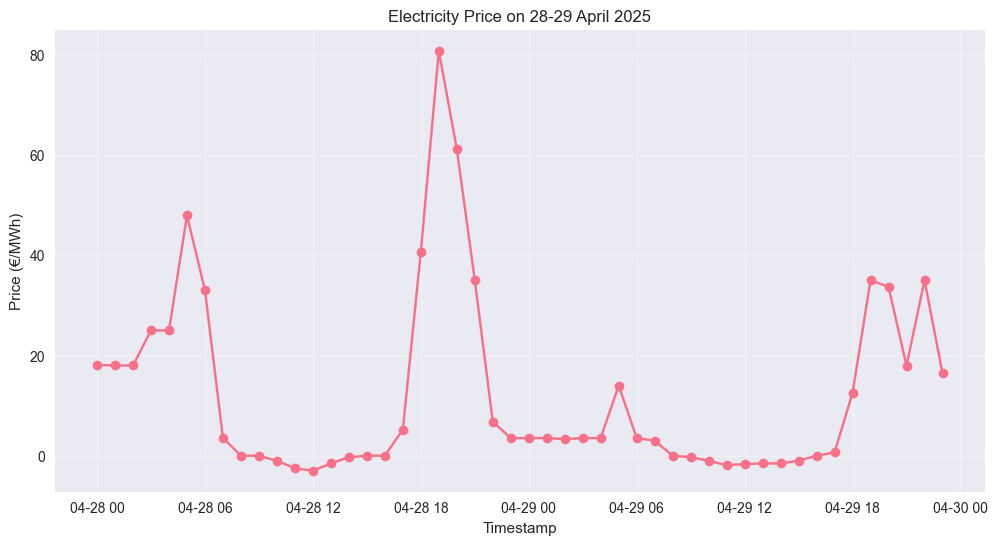

In [78]:
# start end of dataset
start_date = Dataset_indexed.index.min()
end_date = Dataset_indexed.index.max()
print(f"\nDataset time range: {start_date} to {end_date}")


# analysis of 28-29 april 2025
mask_april = (Dataset_indexed.index >= '2025-04-28') & (Dataset_indexed.index < '2025-04-30')
april_data = Dataset_indexed.loc[mask_april]
plt.figure(figsize=(12,6))
plt.plot(april_data.index, april_data['spot_price_spain'], marker='o')
plt.title('Electricity Price on 28-29 April 2025')
plt.xlabel('Timestamp'); plt.ylabel('Price (€/MWh)')
plt.grid(True, alpha=0.3)
plt.show()

# don't eliminate these 2 days from the dataset, because for a time series continuity it's better to keep them


## **Key Findings from EDA **

#### **1. Strong temporal patterns**
Electricity prices exhibit clear intraday, weekly, and seasonal structures. Hourly profiles show systematic evening peaks, while weekday–weekend and monthly effects highlight recurring demand and generation cycles.
#### **2. Main price drivers**
Combined-cycle gas turbines and coal-fired generation display the strongest positive correlation with prices, confirming their role as marginal technologies. Renewable generation, particularly solar and wind, shows a clear negative correlation with prices.
#### **3. Demand has limited explanatory power**
Electricity demand is only moderately correlated with price (≈0.28–0.30), reflecting the relatively inelastic nature of consumption in the short term.
#### **4. Hydraulic generation behaves as expected**
Hydroelectric generation shows weak and unstable correlation with prices, consistent with its role as a flexible balancing resource rather than a systematic price driver.
#### **5. Strong autocorrelation**
Spot prices exhibit strong short- and medium-term autocorrelation, supporting the inclusion of lagged price features to capture temporal persistence.
#### **6. Data quality checks**
Missing values, zero entries, and anomalies were identified and quantified. No critical issues affecting model validity were detected after preprocessing.



# Task 2 Feature Selection

This section describes the methodology employed to identify an appropriate set of predictor variables for the day-ahead electricity price forecasting model.

### Problem formulation

The forecasting task is defined as follows: given information available on day D−1, predict the 24 hourly marginal prices for day D in the Spanish wholesale electricity market (OMIE). The target variable is `spot_price_spain`, expressed in €/MWh. The temporal resolution is hourly.

### Data leakage prevention

To ensure the validity of the forecasting exercise, the feature set is restricted to variables that are observable at the time of prediction, i.e., prior to market clearing on day D−1. The use of ex-post information would result in data leakage and artificially inflated performance metrics.

The following variable categories satisfy this temporal constraint:

- **Scheduled generation** (`scheduled_*`): day-ahead generation schedules submitted to the market operator, available before delivery.
- **Lagged prices** (`price_t-24`, `price_t-72`, `price_t-168`, `price_t-336`): historical prices from preceding periods.
- **Lagged demand** (`demand_t-24`, etc.): realised demand from previous periods.
- **Calendar features** (`hour`, `day_of_week`, `month`): deterministic temporal indicators.
- **Day-ahead cleared energy** (`dam_allocated_energy_spain`): total energy allocated in the day-ahead auction, known after market closure on D−1.

Realised generation variables (`actual_*`) are excluded from the modelling framework, as these represent ex-post observations that are unavailable at the time of forecasting.

### Candidate predictor set

Based on the above constraints, 20 candidate variables are retained for preliminary analysis:

| Category | Variables |
|----------|-----------|
| Scheduled generation | `scheduled_demand`, `scheduled_coal`, `scheduled_combined_cycle`, `scheduled_wind`, `scheduled_hydraulic`, `scheduled_total_import`, `scheduled_nuclear`, `scheduled_solar_pv` |
| Market energy | `dam_allocated_energy_spain` |
| Calendar | `hour`, `day_of_week`, `month` |
| Lagged prices | `price_t-24`, `price_t-72`, `price_t-168`, `price_t-336` |
| Lagged demand | `demand_t-24`, `demand_t-72`, `demand_t-168`, `demand_t-336` |

### Selection methodology

The final feature set is determined through the following analytical steps:

1. **Univariate correlation analysis.** Pearson correlation coefficients are computed between each candidate variable and the target. Variables exhibiting higher absolute correlation are considered more informative.

2. **Multicollinearity assessment.** The pairwise correlation matrix among predictors is examined to identify redundant variable pairs (|r| > 0.95). Highly correlated features introduce redundancy and may destabilise coefficient estimation in linear models.

3. **Data quality evaluation.** Each variable is assessed for missing values, zero-value frequencies, and range anomalies. Variables with substantial missing data require imputation or exclusion.

4. **Domain-informed interpretation.** The selection incorporates knowledge of electricity market economics:
   - Combined-cycle gas turbines (CCGT) and coal-fired plants typically operate as marginal generators and exhibit strong positive correlation with price.
   - Renewable sources (wind, solar photovoltaic) have near-zero marginal cost and exert downward pressure on prices when generation is high.
   - Hydroelectric generation provides system flexibility but does not consistently drive marginal prices.
   - Nuclear generation operates as base-load capacity with stable output and limited price sensitivity.
   - Demand exhibits moderate correlation with price due to the relative inelasticity of electricity consumption.


# Step 3 ( Task 2 ): Feature Selection Analysis


In [79]:
# ---------------------------
# Lag features
# ---------------------------
Dataset_lag = Dataset_indexed.copy()
Dataset_lag['price_t-24'] = Dataset_lag['spot_price_spain'].shift(24)  # 1 day lag
Dataset_lag['price_t-72'] = Dataset_lag['spot_price_spain'].shift(72)  # 3 days lag
Dataset_lag['price_t-168'] = Dataset_lag['spot_price_spain'].shift(168)  # 1 week lag
Dataset_lag['price_t-336'] = Dataset_lag['spot_price_spain'].shift(336)  # 2 weeks lag

Dataset_lag['demand_t-24'] = Dataset_lag['actual_national_demand'].shift(24)  # 1 day lag
Dataset_lag['demand_t-72'] = Dataset_lag['actual_national_demand'].shift(72)  # 3 days lag
Dataset_lag['demand_t-168'] = Dataset_lag['actual_national_demand'].shift(168)  # 1 week lag
Dataset_lag['demand_t-336'] = Dataset_lag['actual_national_demand'].shift(336)  # 2 weeks lag

print(Dataset_lag.columns.tolist())

print("Lag features preview:")
print(Dataset_lag[['spot_price_spain', 'price_t-24', 'price_t-72', 'price_t-168', 'price_t-336', 'actual_national_demand', 'demand_t-24','demand_t-72', 'demand_t-168', 'demand_t-336']].head(48))

# Correlation of lagged prices with current price
lag_correlations = Dataset_lag[['spot_price_spain', 'price_t-24', 'price_t-72', 'price_t-168', 'price_t-336']].corr()
print("\nCorrelation of lagged prices with current price:")
print(lag_correlations['spot_price_spain'].sort_values(ascending=False))

['scheduled_demand', 'actual_national_demand', 'dam_allocated_energy_spain', 'scheduled_coal', 'scheduled_combined_cycle', 'scheduled_wind', 'scheduled_hydraulic', 'scheduled_total_import', 'scheduled_nuclear', 'scheduled_solar_pv', 'actual_coal_generation', 'actual_combined_cycle_generation', 'actual_wind_generation', 'actual_hydraulic_generation', 'actual_nuclear_generation', 'actual_solar_pv_generation', 'hour', 'day_of_week', 'month', 'spot_price_spain', 'Year', 'price_t-24', 'price_t-72', 'price_t-168', 'price_t-336', 'demand_t-24', 'demand_t-72', 'demand_t-168', 'demand_t-336']
Lag features preview:
                     spot_price_spain  price_t-24  price_t-72  price_t-168  \
timestamp                                                                    
2022-08-31 22:00:00            200.00         NaN         NaN          NaN   
2022-08-31 23:00:00            181.99         NaN         NaN          NaN   
2022-09-01 00:00:00            178.54         NaN         NaN          NaN 

In [80]:
# Initial feature set

feature_cols_phys = [
    'scheduled_demand',
    'scheduled_coal',
    'scheduled_combined_cycle',
    'scheduled_wind',
    'scheduled_hydraulic',
    'scheduled_total_import',
    'scheduled_nuclear',
    'scheduled_solar_pv',
    'dam_allocated_energy_spain',
    'hour', 'day_of_week', 'month',
    'price_t-24', 'price_t-72', 'price_t-168', 'price_t-336',
    'demand_t-24', 'demand_t-72', 'demand_t-168', 'demand_t-336'
]

# Feature Matrix and Target Vector
X_all = Dataset_lag[feature_cols_phys].copy()
y_all = Dataset_lag['spot_price_spain'].copy()

print("Number of features:", len(feature_cols_phys))
print("X_all shape:", X_all.shape)
print("y_all shape:", y_all.shape)


Number of features: 20
X_all shape: (26304, 20)
y_all shape: (26304,)


In [81]:
# This cell analyzes features for data quality, correlation with target,
# and multicollinearity among features.

print("=" * 80)
print("FEATURE SELECTION ANALYSIS FOR DAY-AHEAD PRICE FORECASTING")
print("=" * 80)

# -----------------------------------------------------------------------------
# DATA QUALITY: Missing values, zeros, min/max for each feature
print("\n" + "=" * 80)
print("DATA QUALITY SUMMARY FOR EACH FEATURE")
print("=" * 80)

quality_data = []
for col in feature_cols_phys:
    n_missing = X_all[col].isna().sum()
    n_zeros = (X_all[col] == 0).sum()
    pct_zeros = 100 * n_zeros / len(X_all)
    col_min = X_all[col].min()
    col_max = X_all[col].max()
    quality_data.append({
        'Feature': col,
        'Missing': n_missing,
        'Zeros': n_zeros,
        'Zeros %': f"{pct_zeros:.2f}%",
        'Min': col_min,
        'Max': col_max
    })

quality_df = pd.DataFrame(quality_data)
print("\n")
print(quality_df.to_string(index=False))

# Highlight problematic features
print("\n--- Data Quality Issues ---")
for row in quality_data:
    issues = []
    if row['Missing'] > 0:
        issues.append(f"{row['Missing']} missing values")
    if row['Zeros'] > 100 and 'hour' not in row['Feature'] and 'day_of_week' not in row['Feature']:
        issues.append(f"{row['Zeros']} zeros ({row['Zeros %']})")
    if issues:
        print(f"  {row['Feature']}: {', '.join(issues)}")

# -----------------------------------------------------------------------------
# CORRELATION WITH TARGET (spot_price_spain)
print("\n" + "=" * 80)
print("PEARSON CORRELATION WITH TARGET (spot_price_spain)")
print("=" * 80)

# Compute correlations (using pairwise complete observations)
correlations_with_target = []
for col in feature_cols_phys:
    # Use only rows where both feature and target are not NaN
    valid_mask = X_all[col].notna() & y_all.notna()
    corr = X_all.loc[valid_mask, col].corr(y_all[valid_mask])
    correlations_with_target.append({
        'Feature': col,
        'Correlation': corr,
        'Abs_Corr': abs(corr)
    })

# Sort by absolute correlation, descending
corr_df = pd.DataFrame(correlations_with_target)
corr_df = corr_df.sort_values('Abs_Corr', ascending=False).reset_index(drop=True)

print("\nFeatures sorted by |correlation| with spot_price_spain:\n")
print(f"{'Rank':<5} {'Feature':<30} {'Correlation':>12} {'|Corr|':>10}")
print("-" * 60)
for i, row in corr_df.iterrows():
    print(f"{i+1:<5} {row['Feature']:<30} {row['Correlation']:>12.4f} {row['Abs_Corr']:>10.4f}")

# Categorize features by correlation strength
print("\n--- Feature Importance Categories ---")
strong = corr_df[corr_df['Abs_Corr'] >= 0.5]['Feature'].tolist()
moderate = corr_df[(corr_df['Abs_Corr'] >= 0.2) & (corr_df['Abs_Corr'] < 0.5)]['Feature'].tolist()
weak = corr_df[corr_df['Abs_Corr'] < 0.2]['Feature'].tolist()

print(f"  STRONG (|r| >= 0.5):   {strong}")
print(f"  MODERATE (0.2-0.5):    {moderate}")
print(f"  WEAK (|r| < 0.2):      {weak}")

# -----------------------------------------------------------------------------
# MULTICOLLINEARITY: Feature-Feature Correlation Matrix
print("\n" + "=" * 80)
print("MULTICOLLINEARITY CHECK (|corr| > 0.95 among features)")
print("=" * 80)

# Compute correlation matrix among features
feature_corr_matrix = X_all[feature_cols_phys].corr()

# Find pairs with |corr| > 0.95
high_corr_pairs = []
for i, col1 in enumerate(feature_cols_phys):
    for j, col2 in enumerate(feature_cols_phys):
        if i < j:  # Only upper triangle
            corr_val = feature_corr_matrix.loc[col1, col2]
            if abs(corr_val) > 0.95:
                high_corr_pairs.append((col1, col2, corr_val))

if high_corr_pairs:
    print(f"\nFound {len(high_corr_pairs)} highly correlated feature pair(s):\n")
    for col1, col2, corr_val in high_corr_pairs:
        print(f"  {col1} <--> {col2}")
        print(f"    Correlation: {corr_val:.4f}")
        
        # Provide recommendation
        # Check which one has higher correlation with target
        corr1 = corr_df[corr_df['Feature'] == col1]['Abs_Corr'].values[0]
        corr2 = corr_df[corr_df['Feature'] == col2]['Abs_Corr'].values[0]
        
        # Logic for recommendation
        if 'price_t-' in col1 and 'price_t-' in col2:
            # Both are price lags - keep shorter lag
            lag1 = int(col1.split('-')[1])
            lag2 = int(col2.split('-')[1])
            keep = col1 if lag1 < lag2 else col2
            drop = col2 if lag1 < lag2 else col1
            print(f"    Suggestion: KEEP '{keep}' (shorter lag, more recent info), consider dropping '{drop}'")
        elif 'demand_t-' in col1 and 'demand_t-' in col2:
            # Both are demand lags - keep shorter lag
            lag1 = int(col1.split('-')[1])
            lag2 = int(col2.split('-')[1])
            keep = col1 if lag1 < lag2 else col2
            drop = col2 if lag1 < lag2 else col1
            print(f"    Suggestion: KEEP '{keep}' (shorter lag), consider dropping '{drop}'")
        elif corr1 > corr2:
            print(f"    Suggestion: KEEP '{col1}' (higher target correlation: {corr1:.3f} vs {corr2:.3f})")
        else:
            print(f"    Suggestion: KEEP '{col2}' (higher target correlation: {corr2:.3f} vs {corr1:.3f})")
        print()
else:
    print("\nNo feature pairs with |correlation| > 0.95 found.")
    print("Multicollinearity is not a major concern for this feature set.")

# Also check pairs with |corr| > 0.85 for awareness
moderate_corr_pairs = []
for i, col1 in enumerate(feature_cols_phys):
    for j, col2 in enumerate(feature_cols_phys):
        if i < j:
            corr_val = feature_corr_matrix.loc[col1, col2]
            if 0.85 < abs(corr_val) <= 0.95:
                moderate_corr_pairs.append((col1, col2, corr_val))

if moderate_corr_pairs:
    print(f"\nAdditional pairs with 0.85 < |corr| <= 0.95 (moderate multicollinearity):")
    for col1, col2, corr_val in moderate_corr_pairs:
        print(f"  {col1} <--> {col2}: {corr_val:.4f}")

# -----------------------------------------------------------------------------
# SUMMARY 
print("\n" + "=" * 80)
print("FEATURE SELECTION SUMMARY")
print("=" * 80)

print("""
CLEARLY IMPORTANT FEATURES (high correlation with price):
---------------------------------------------------------
• price_t-24, price_t-168: Lagged prices are the strongest predictors.
  Day-ahead and weekly price patterns are highly autocorrelated.
  
• scheduled_combined_cycle: CCGT is the marginal price setter in Spain.
  When CCGT runs more, prices tend to be higher (positive correlation).
  
• scheduled_coal: Coal also acts as marginal generator during peak demand.

• scheduled_solar_pv, scheduled_wind: Renewables push prices DOWN 
  (negative correlation). More renewable generation = lower prices.

MODERATE IMPORTANCE:
--------------------
• hour, day_of_week, month: Temporal features capture daily/weekly/seasonal
  price patterns. Essential for capturing periodicity.
  
• scheduled_demand, dam_allocated_energy_spain: Demand-side features have
  moderate correlation (~0.28-0.35). Price is somewhat inelastic to demand.
  
• demand_t-24, demand_t-168: Lagged demand adds temporal context.

WEAK OR POTENTIALLY REDUNDANT FEATURES:
---------------------------------------
• scheduled_hydraulic: Low correlation; hydro acts as flexible balancing
  (pumping/generating) rather than price driver.
  
• scheduled_nuclear: Base-load generation, very stable output, weak price signal.

• scheduled_total_import: Low correlation; imports balance supply/demand
  but don't strongly drive marginal price.

• price_t-72, price_t-336, demand_t-72, demand_t-336: Longer lags have
  lower correlation. Consider keeping only t-24 and t-168 to reduce
  redundancy if multicollinearity is an issue.

DATA QUALITY ISSUES TO ADDRESS:
-------------------------------
• scheduled_coal: ~1,224 missing values (4.65%) - needs imputation or
  careful handling. Forward-fill or median imputation recommended.
  
• scheduled_solar_pv: ~783 missing values (2.98%) - same treatment.

• Lag features (price_t-*, demand_t-*): First 336 rows have NaN due to
  shifting. These rows must be dropped before training.

• scheduled_demand: 35 zeros (anomalous) - investigate or impute.

NEXT STEPS:
-----------
1. Handle missing values (imputation or drop)
2. Consider dropping highly redundant long-lag features (t-336)
3. Proceed to train/test split
4. Train baseline models and evaluate feature importance empirically
""")

print("=" * 80)
print("END OF FEATURE SELECTION ANALYSIS")
print("=" * 80)


FEATURE SELECTION ANALYSIS FOR DAY-AHEAD PRICE FORECASTING

DATA QUALITY SUMMARY FOR EACH FEATURE


                   Feature  Missing  Zeros Zeros %         Min       Max
          scheduled_demand        2     35   0.13%    0.000000 39866.750
            scheduled_coal     1224      0   0.00%   15.000000  1655.000
  scheduled_combined_cycle       38      0   0.00%  302.900000 17054.625
            scheduled_wind       38      0   0.00%  301.125000 21271.000
       scheduled_hydraulic       38      0   0.00%  148.125000  9393.675
    scheduled_total_import      126      0   0.00%    0.200000  8100.325
         scheduled_nuclear       38      0   0.00%  142.000000 12101.400
        scheduled_solar_pv      783      0   0.00%    0.025000 22889.516
dam_allocated_energy_spain       15      0   0.00%   80.300000 36294.900
                      hour        0   1096   4.17%    0.000000    23.000
               day_of_week        0   3744  14.23%    0.000000     6.000
                     mon

### Selected predictor variables

Following the application of the selection methodology described above, 14 variables are retained for the final model. Table 1 summarises the selected features and their rationale.

**Table 1.** Final predictor set for the day-ahead price forecasting model.

| Category | Variables | Selection rationale |
|----------|-----------|---------------------|
| Lagged prices | `price_t-24`, `price_t-72`, `price_t-168`, `price_t-336` | Exhibit the highest correlation with the target; capture autocorrelation structure and weekly periodicity |
| Marginal generation (CCGT) | `scheduled_combined_cycle` | Combined-cycle plants frequently set the marginal price; strongest positive correlation among generation variables |
| Renewable generation | `scheduled_solar_pv`, `scheduled_wind` | Negative correlation with price; high renewable output depresses marginal prices |
| Day-ahead-market | `dam_allocated_energy_spain` | How much energy was allocated in the day-ahead-market|
| Demand | `scheduled_demand`, `demand_t-24` | Captures load level and short-term demand dynamics |
| Calendar | `hour`, `day_of_week`, `month` | Encodes intra-day, weekly, and seasonal price patterns |
| Coal generation | `scheduled_coal` | Secondary marginal technology during peak demand periods |

### Excluded variables

The following variables were excluded from the final predictor set:

| Variable | Exclusion rationale |
|----------|---------------------|
| `scheduled_hydraulic` | Weak correlation with price; hydroelectric units primarily provide ancillary services and flexibility |
| `scheduled_nuclear` | Operates as base-load generation with stable output; negligible marginal price influence |
| `scheduled_total_import` | Low correlation; cross-border flows balance supply and demand but do not determine marginal prices |
| `demand_t-72`, `demand_t-168`, `demand_t-336` | Redundant with `demand_t-24`; exhibit weaker correlation and introduce multicollinearity risk |
| All `actual_*` variables | Excluded to prevent data leakage; realised generation is unavailable at prediction time |

This concludes the feature selection phase (Section 3). The subsequent section describes the construction of the modelling dataset.


## Dataset Construction

This section describes the preprocessing steps applied to construct the final modelling dataset (`Dataset_ml`) from the selected predictor variables.

### Missing value treatment

Missing values in the scheduled generation variables (`scheduled_coal`, `scheduled_solar_pv`, `scheduled_combined_cycle`, `scheduled_wind`, `scheduled_demand`, and related fields) are imputed with zero. This approach is justified by the observation that an absent schedule entry typically indicates no planned generation or import for the corresponding hour. The same imputation strategy is applied to `dam_allocated_energy_spain`.

### Removal of lag-induced incomplete observations

The construction of lagged features introduces missing values in the initial portion of the time series. Specifically, variables such as `price_t-336` and `demand_t-24` contain undefined values for the first 336 and 24 observations, respectively. These incomplete records are removed to ensure that all observations in the modelling dataset contain valid entries for all predictor variables.

### Final dataset specification

Following the preprocessing steps described above, the resulting dataset (`Dataset_ml`) has the following characteristics:

- **Predictor variables:** 14 (as defined in `feature_cols_final`)
- **Target variable:** `spot_price_spain`
- **Missing values:** None
- **Temporal coverage:** 2022-09-14 22:00 to 2025-08-31 21:00 (hourly resolution)
- **Sample size:** Approximately 25,885 observations

The dataset is now prepared for the temporal train/test partitioning described in the following section.


In [82]:
missing_idx = df.index[df['dam_allocated_energy_spain'].isna()]

for idx in missing_idx[:10]:  # print first 10 for brevity
    prev_val = df['dam_allocated_energy_spain'].shift(1).loc[idx]
    next_val = df['dam_allocated_energy_spain'].shift(-1).loc[idx]
    print(f"Index: {idx}, prev={prev_val}, next={next_val}")


Index: 2025-04-28 14:00:00, prev=96.7, next=nan
Index: 2025-04-28 15:00:00, prev=nan, next=nan
Index: 2025-04-28 16:00:00, prev=nan, next=nan
Index: 2025-04-28 17:00:00, prev=nan, next=279.9
Index: 2025-04-29 07:00:00, prev=1364.1, next=nan
Index: 2025-04-29 08:00:00, prev=nan, next=nan
Index: 2025-04-29 09:00:00, prev=nan, next=nan
Index: 2025-04-29 10:00:00, prev=nan, next=833.8
Index: 2025-04-29 13:00:00, prev=80.3, next=nan
Index: 2025-04-29 14:00:00, prev=nan, next=nan


In [83]:
# ================================
# Task 2 - Step 3b: Final Feature Selection & Data Preparation
# ================================
# Based on the feature selection analysis, we define the final feature set
# (physically and statistically motivated) and prepare a clean dataframe for modeling.

# -----------------------------------------------------------------------------
# Define final feature list (14 features)

# Selected based on:
#   - Statistical correlation with SPOT price
#   - Physical meaning in the electricity market context
#   - Availability at prediction time (day-ahead forecasting)

feature_cols_final = [
    # Lagged prices - strongest predictors due to autocorrelation
    'price_t-24',
    'price_t-72',
    'price_t-168',
    'price_t-336',

    # Marginal generator (CCGT) - price setter 
    'scheduled_combined_cycle',

    # Renewables - push prices down 
    'scheduled_solar_pv',
    'scheduled_wind',

    # Energy allocated in the day ahead market 
    'dam_allocated_energy_spain',

    # Demand level and short lag
    'scheduled_demand',
    'demand_t-24',

    # Time features - capture daily/weekly/seasonal patterns
    'hour',
    'day_of_week',
    'month',

    # Coal - marginal generator during peak periods
    'scheduled_coal'
]

print("=" * 70)
print("FINAL FEATURE SET FOR MODELING")
print("=" * 70)
print(f"\nNumber of features: {len(feature_cols_final)}")
print("\nFeatures:")
for i, feat in enumerate(feature_cols_final, 1):
    print(f"  {i:2d}. {feat}")

# -----------------------------------------------------------------------------
# Create working copy and handle missing values
print("\n" + "-" * 70)
print("Handling missing values...")
print("-" * 70)

df = Dataset_lag.copy()

# Fill missing values for scheduled generation features with 0.0
# Rationale: no schedule typically means no planned generation/import
scheduled_cols_to_fill = [
    'scheduled_coal', 
    'scheduled_solar_pv', 
    'scheduled_total_import',
    'scheduled_combined_cycle',
    'scheduled_wind',
    'scheduled_hydraulic',
    'scheduled_nuclear',
    'scheduled_demand'
]

for col in scheduled_cols_to_fill:
    if col in df.columns:
        n_missing_before = df[col].isna().sum()
        df[col] = df[col].fillna(0.0)
        if n_missing_before > 0:
            print(f"  Filled {n_missing_before} missing values in '{col}' with 0.0")

# Also fill dam_allocated_energy_spain if it has missing values
if 'dam_allocated_energy_spain' in df.columns:
    n_missing = df['dam_allocated_energy_spain'].isna().sum()
    if n_missing > 0:
        df['dam_allocated_energy_spain'] = df['dam_allocated_energy_spain'].interpolate(method='linear')
        df['dam_allocated_energy_spain']= df['dam_allocated_energy_spain'].fillna(method='ffill')
        print(f"  Interpolated {n_missing} missing values in 'dam_allocated_energy_spain' ")

# -----------------------------------------------------------------------------
# Build clean modeling dataframe
# Select only the final features + target
cols_for_ml = feature_cols_final + ['spot_price_spain']

Dataset_ml = df[cols_for_ml].copy()

# Drop rows with any remaining NaN values
# (mainly the first rows affected by lag features - up to 336 hours)
n_before = len(Dataset_ml)
Dataset_ml = Dataset_ml.dropna()
n_after = len(Dataset_ml)
n_dropped = n_before - n_after

print(f"\nDropped {n_dropped} rows with NaN values (lag-induced NaNs at the beginning)")

# -----------------------------------------------------------------------------
# Summary statistics
# -----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("CLEAN MODELING DATAFRAME: Dataset_ml")
print("=" * 70)

print(f"\nfeature_cols_final = {feature_cols_final}")

print(f"\nDataset_ml.shape = {Dataset_ml.shape}")
print(f"  - Rows (hourly observations): {Dataset_ml.shape[0]}")
print(f"  - Columns: {Dataset_ml.shape[1]} ({len(feature_cols_final)} features + 1 target)")

print(f"\nMissing values per column:")
missing_per_col = Dataset_ml.isna().sum()
print(missing_per_col.to_string())

print(f"\nTime range covered:")
print(f"  - Min timestamp: {Dataset_ml.index.min()}")
print(f"  - Max timestamp: {Dataset_ml.index.max()}")

if missing_per_col.sum() == 0:
    print("\n No missing values remain. Dataset_ml is ready for train/test split.")
else:
    print(f"\n Warning: {missing_per_col.sum()} missing values remain!")

print("\n" + "=" * 70)
print("Dataset_ml is ready for the next step (temporal train/test split)")
print("=" * 70)



FINAL FEATURE SET FOR MODELING

Number of features: 14

Features:
   1. price_t-24
   2. price_t-72
   3. price_t-168
   4. price_t-336
   5. scheduled_combined_cycle
   6. scheduled_solar_pv
   7. scheduled_wind
   8. dam_allocated_energy_spain
   9. scheduled_demand
  10. demand_t-24
  11. hour
  12. day_of_week
  13. month
  14. scheduled_coal

----------------------------------------------------------------------
Handling missing values...
----------------------------------------------------------------------


  Filled 1224 missing values in 'scheduled_coal' with 0.0
  Filled 783 missing values in 'scheduled_solar_pv' with 0.0
  Filled 126 missing values in 'scheduled_total_import' with 0.0
  Filled 38 missing values in 'scheduled_combined_cycle' with 0.0
  Filled 38 missing values in 'scheduled_wind' with 0.0
  Filled 38 missing values in 'scheduled_hydraulic' with 0.0
  Filled 38 missing values in 'scheduled_nuclear' with 0.0
  Filled 2 missing values in 'scheduled_demand' with 0.0
  Interpolated 15 missing values in 'dam_allocated_energy_spain' 

Dropped 419 rows with NaN values (lag-induced NaNs at the beginning)

CLEAN MODELING DATAFRAME: Dataset_ml

feature_cols_final = ['price_t-24', 'price_t-72', 'price_t-168', 'price_t-336', 'scheduled_combined_cycle', 'scheduled_solar_pv', 'scheduled_wind', 'dam_allocated_energy_spain', 'scheduled_demand', 'demand_t-24', 'hour', 'day_of_week', 'month', 'scheduled_coal']

Dataset_ml.shape = (25885, 15)
  - Rows (hourly observations): 25885
  - Colum

---

##  Summary of previous sections ; reader checkpoint  


The following stages of the project have been completed:

1. **Exploratory data analysis.** Descriptive statistics, temporal pattern analysis (hourly, daily, weekly, seasonal), correlation structure examination, and identification of principal price drivers (CCGT, coal, renewable generation).

2. **Feature engineering.** Construction of lagged price variables (`price_t-24`, `price_t-72`, `price_t-168`, `price_t-336`) and lagged demand variables to capture temporal dependencies.

3. **Feature selection.** Systematic evaluation of 20 candidate predictors using correlation analysis, multicollinearity assessment, data quality review, and domain-informed reasoning. A final set of 14 predictor variables has been selected.

4. **Dataset preparation.** Construction of the modelling dataset (`Dataset_ml`) containing 14 predictors and the target variable, with no missing values. The dataset comprises approximately 25,885 hourly observations spanning September 2022 to August 2025.

---

The following final part of the notebook focuses on the supervised forecasting task and includes:

1. **Temporal data partitioning.** Implementation of a chronological train/test split, with the test set corresponding to September 2025.
2. **Model development.** Training of candidate regression models (e.g., linear regression, random forest, gradient boosting) using the training partition.

3. **Hyperparameter optimisation.** Systematic tuning of model hyperparameters using cross-validation on the training data.

4. **Model evaluation.** Assessment of predictive performance on the held-out test set using standard regression metrics (RMSE, MAE, R²).

5. **Submission.** Generation of forecasts for the September 2025 evaluation period.



In [84]:
train_df = Dataset_ml
tscv = TimeSeriesSplit(n_splits=6)

X = train_df[feature_cols_final] #features
y = train_df['spot_price_spain'] #target

for fold, (train_idx, val_idx) in enumerate(tscv.split(X)): 
    print(f"Fold {fold+1}")
    print(f"Train: {train_idx[0]} to {train_idx[-1]}  ({len(train_idx)})")
    print(f"Validation: {val_idx[0]} to {val_idx[-1]}  ({len(val_idx)})")
    print('')



Fold 1
Train: 0 to 3702  (3703)
Validation: 3703 to 7399  (3697)

Fold 2
Train: 0 to 7399  (7400)
Validation: 7400 to 11096  (3697)

Fold 3
Train: 0 to 11096  (11097)
Validation: 11097 to 14793  (3697)

Fold 4
Train: 0 to 14793  (14794)
Validation: 14794 to 18490  (3697)

Fold 5
Train: 0 to 18490  (18491)
Validation: 18491 to 22187  (3697)

Fold 6
Train: 0 to 22187  (22188)
Validation: 22188 to 25884  (3697)



 
Evaluating: GBR
 
Fold 1 RMSE: 22.70 | R²: 0.681
Fold 2 RMSE: 16.23 | R²: 0.824
Fold 3 RMSE: 23.44 | R²: 0.560
Fold 4 RMSE: 19.86 | R²: 0.765
Fold 5 RMSE: 20.73 | R²: 0.806
Fold 6 RMSE: 27.14 | R²: 0.665
 
Evaluating: RFR
 
Fold 1 RMSE: 22.13 | R²: 0.697
Fold 2 RMSE: 16.94 | R²: 0.808
Fold 3 RMSE: 24.50 | R²: 0.519
Fold 4 RMSE: 19.20 | R²: 0.780
Fold 5 RMSE: 21.27 | R²: 0.796
Fold 6 RMSE: 26.09 | R²: 0.690
 
Evaluating: MLP
 
Fold 1 RMSE: 22.42 | R²: 0.689
Fold 2 RMSE: 16.48 | R²: 0.818
Fold 3 RMSE: 21.38 | R²: 0.634
Fold 4 RMSE: 17.03 | R²: 0.827
Fold 5 RMSE: 20.18 | R²: 0.816
Fold 6 RMSE: 21.21 | R²: 0.795
 
Evaluating: LR
 
Fold 1 RMSE: 21.17 | R²: 0.722
Fold 2 RMSE: 16.28 | R²: 0.823
Fold 3 RMSE: 17.77 | R²: 0.747
Fold 4 RMSE: 18.66 | R²: 0.793
Fold 5 RMSE: 21.19 | R²: 0.798
Fold 6 RMSE: 17.72 | R²: 0.857
 
Evaluating: SVR
 
Fold 1 RMSE: 25.67 | R²: 0.592
Fold 2 RMSE: 19.74 | R²: 0.739
Fold 3 RMSE: 26.02 | R²: 0.458
Fold 4 RMSE: 18.82 | R²: 0.789
Fold 5 RMSE: 22.41 | R²: 0.774
Fo

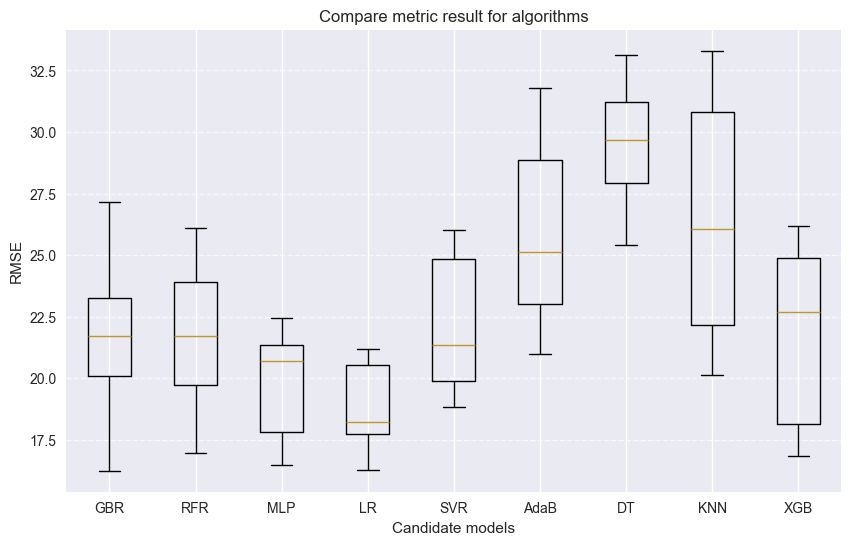

In [85]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import (GradientBoostingRegressor, RandomForestRegressor, AdaBoostRegressor)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, ElasticNet
from xgboost import XGBRegressor
import warnings
# Suppress specific warnings from sklearn (like ConvergenceWarning)
warnings.filterwarnings("ignore")

models = {
    "GBR": GradientBoostingRegressor(random_state=42),
    "RFR": RandomForestRegressor(random_state=42, n_estimators=300),
    "MLP": MLPRegressor(random_state=42, max_iter=500),
    "LR": LinearRegression(),
    "SVR": SVR(),
    "AdaB": AdaBoostRegressor(random_state=42),
    "DT": DecisionTreeRegressor(random_state=42),
    "KNN": KNeighborsRegressor(),
    "XGB": XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=8, subsample=0.9, colsample_bytree=0.9, random_state=42, objective='reg:squarederror')
}

results_summary = {}

for model_name, model in models.items():
    print(" ")
    print(f"Evaluating: {model_name}")
    print(" ")

    rmse_scores = []
    mae_scores = []
    r2_scores = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X), 1):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        # Scaling
        scaler = MinMaxScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)

        # Train
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_val_scaled)

        rmse_scores.append(np.sqrt(mean_squared_error(y_val, y_pred)))
        mae_scores.append(mean_absolute_error(y_val, y_pred))
        r2_scores.append(r2_score(y_val, y_pred))

        print(f"Fold {fold} RMSE: {rmse_scores[-1]:.2f} | R²: {r2_scores[-1]:.3f}")

    results_summary[model_name] = {
        "RMSE_list": rmse_scores,
        "RMSE_mean": np.mean(rmse_scores),
        "RMSE_std": np.std(rmse_scores),
        "MAE_mean": np.mean(mae_scores),
        "MAE_std": np.std(mae_scores),
        "R2_mean": np.mean(r2_scores),
        "R2_std": np.std(r2_scores),
    }

print(" ")
print("MODEL COMPARISON")
print(" ")
for name, r in results_summary.items():
    print(f" {name}")
    print(f"  RMSE_mean = {r['RMSE_mean']:.2f} ± {r['RMSE_std']:.2f}")
    print(f"  MAE_mean  = {r['MAE_mean']:.2f} ± {r['MAE_std']:.2f}")
    print(f"  R2_mean   = {r['R2_mean']:.3f} ± {r['R2_std']:.3f}")

# Compare results between algorithms
rmse_all_models = []
model_labels = []
for model_name, metrics in results_summary.items():
    rmse_all_models.append(metrics["RMSE_list"])
    model_labels.append(model_name)

plt.figure(figsize=(10, 6))
plt.boxplot(rmse_all_models)
plt.xticks(range(1, len(model_labels)+1), model_labels)
plt.xlabel('Candidate models')
plt.ylabel("RMSE")
plt.title("Compare metric result for algorithms")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


Thanks to models comparison, it can be stated that LR is the most suitable with the lesser RMSE, MAE and R2.

Linear Regression offers better performance and stability, so there is no need to explore greater complexity as linear regression doesn't have relevant hyperparameters.

GBR could be tuned but there's risk of overfitting

# Test Target: Spot Price — September 2025

### loading and retrieving datasets
The realised spot prices for September 2025 are first loaded and used as the
evaluation target. The corresponding scheduled demand, generation,
and day-ahead allocated energy are retrieved to build a feature set consistent
with the training data.

### Datetime alignment and feature consistency

The test features are then concatenated with the historical dataset in order to
reconstruct lagged price and demand variables.  


In [86]:
df_test_raw = pd.read_csv("test_PrecioMercadoSPOTDiario_Sept2025.csv", sep=";", parse_dates=["datetime"])
df_test_raw = df_test_raw.set_index("datetime").sort_index()
df_test_raw = df_test_raw.rename(columns={"value": "spot_price_spain"})
print(df_test_raw.head())
print(df_test_raw.shape)
df_test_raw.index = pd.to_datetime(df_test_raw.index, utc=True).tz_convert(None)


                            id                               name  geoid  \
datetime                                                                   
2025-09-01 00:00:00+02:00  600  Precio mercado SPOT Diario España      3   
2025-09-01 01:00:00+02:00  600  Precio mercado SPOT Diario España      3   
2025-09-01 02:00:00+02:00  600  Precio mercado SPOT Diario España      3   
2025-09-01 03:00:00+02:00  600  Precio mercado SPOT Diario España      3   
2025-09-01 04:00:00+02:00  600  Precio mercado SPOT Diario España      3   

                          geoname  spot_price_spain  
datetime                                             
2025-09-01 00:00:00+02:00  España             35.79  
2025-09-01 01:00:00+02:00  España             18.07  
2025-09-01 02:00:00+02:00  España             22.34  
2025-09-01 03:00:00+02:00  España             17.64  
2025-09-01 04:00:00+02:00  España             15.00  
(720, 5)


In [87]:
#September 2025

df_dem = pd.read_csv("export_DemandaProgramadaP48Total_2025-12-08_14_50.csv", sep=";", parse_dates=["datetime"]).set_index("datetime")
df_dam = pd.read_csv("export_EnergiaAsignadaEnMercadoSPOTDiarioEspana_2025-12-08_14_51.csv", sep=";", parse_dates=["datetime"]).set_index("datetime")
df_coal = pd.read_csv("export_GeneracionProgramadaP48Carbon_2025-12-08_14_49.csv", sep=";", parse_dates=["datetime"]).set_index("datetime")
df_ccgt = pd.read_csv("export_GeneracionProgramadaP48CicloCombinado_2025-12-08_14_46.csv", sep=";", parse_dates=["datetime"]).set_index("datetime")
df_wind = pd.read_csv("export_GeneracionProgramadaP48Eolica_2025-12-08_14_48.csv", sep=";", parse_dates=["datetime"]).set_index("datetime")
df_solar = pd.read_csv("export_GeneracionProgramadaP48SolarFotovoltaica_2025-12-08_14_47.csv", sep=";", parse_dates=["datetime"]).set_index("datetime")

print(df_dem.head())
print(df_dem.shape)

df_dem = df_dem[["value"]].rename(columns={"value": "scheduled_demand"})
df_dam = df_dam[["value"]].rename(columns={"value": "dam_allocated_energy_spain"})
df_coal = df_coal[["value"]].rename(columns={"value": "scheduled_coal"})
df_ccgt = df_ccgt[["value"]].rename(columns={"value": "scheduled_combined_cycle"})
df_wind = df_wind[["value"]].rename(columns={"value": "scheduled_wind"})
df_solar = df_solar[["value"]].rename(columns={"value": "scheduled_solar_pv"})

df_test_features = df_dem.copy()

# Merge frame by datetime index
df_test_features = df_test_features.join(df_dam, how="left")
df_test_features = df_test_features.join(df_coal, how="left")
df_test_features = df_test_features.join(df_ccgt, how="left")
df_test_features = df_test_features.join(df_wind, how="left")
df_test_features = df_test_features.join(df_solar, how="left")

print(df_test_features.head())
print(df_test_features.shape)

# Fill missing scheduled with 0
df_test_features["scheduled_wind"] = df_test_features["scheduled_wind"].fillna(0.0)
df_test_features["scheduled_solar_pv"] = df_test_features["scheduled_solar_pv"].fillna(0.0)
df_test_features["scheduled_coal"] = df_test_features["scheduled_coal"].fillna(0.0)
print("Missing values per column:")
print(df_test_features.isna().sum())

df_test_features["dam_allocated_energy_spain"] = \
    df_test_features["dam_allocated_energy_spain"].interpolate(method="linear")

df_test_features["dam_allocated_energy_spain"] = \
    df_test_features["dam_allocated_energy_spain"].fillna(method="ffill")


                              id                          name  geoid  \
datetime                                                                
2025-09-01 00:00:00+02:00  10027  Demanda programada P48 total    NaN   
2025-09-01 01:00:00+02:00  10027  Demanda programada P48 total    NaN   
2025-09-01 02:00:00+02:00  10027  Demanda programada P48 total    NaN   
2025-09-01 03:00:00+02:00  10027  Demanda programada P48 total    NaN   
2025-09-01 04:00:00+02:00  10027  Demanda programada P48 total    NaN   

                           geoname      value  
datetime                                       
2025-09-01 00:00:00+02:00      NaN  23686.575  
2025-09-01 01:00:00+02:00      NaN  22413.425  
2025-09-01 02:00:00+02:00      NaN  21448.675  
2025-09-01 03:00:00+02:00      NaN  20925.425  
2025-09-01 04:00:00+02:00      NaN  20746.900  
(720, 5)
                           scheduled_demand  dam_allocated_energy_spain  \
datetime                                                            

Train: (25549, 14)
Test: (720, 14)
Final Test Metrics for September 2025
RMSE = 21.36
MAE  = 16.26
R²   = 0.752



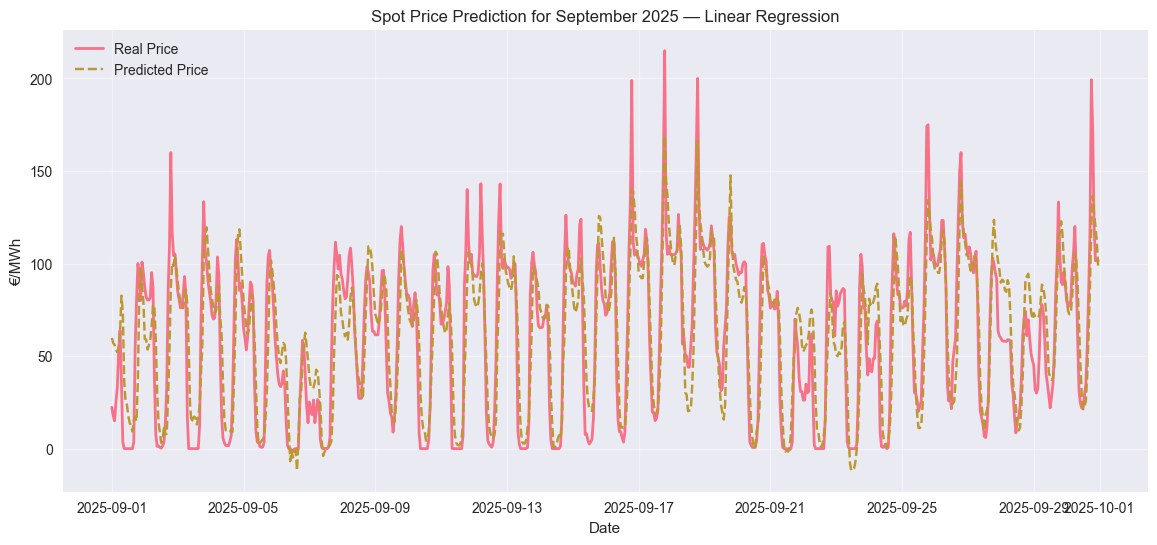

In [88]:
#normalize index, removes duplicates and merge new september features
Dataset_ml.index = pd.to_datetime(Dataset_ml.index).tz_localize(None)
df_test_features.index = pd.to_datetime(df_test_features.index).tz_localize(None)
df_test_raw.index      = pd.to_datetime(df_test_raw.index).tz_localize(None)

df_test_features = df_test_features[~df_test_features.index.duplicated(keep="first")]
df_test_raw = df_test_raw[~df_test_raw.index.duplicated(keep="first")]

df_full = pd.concat([Dataset_ml, df_test_features], axis=0)

df_full["spot_price_spain"] = pd.concat([Dataset_ml["spot_price_spain"], df_test_raw["spot_price_spain"]])

df_full.index = pd.to_datetime(df_full.index)

# generate lag features
df_full["price_t-24"] = df_full["spot_price_spain"].shift(24)
df_full["price_t-72"] = df_full["spot_price_spain"].shift(72)
df_full["price_t-168"] = df_full["spot_price_spain"].shift(168)
df_full["price_t-336"] = df_full["spot_price_spain"].shift(336)

df_full["demand_t-24"] = df_full["scheduled_demand"].shift(24)

# time features
df_full["hour"] = df_full.index.hour
df_full["day_of_week"] = df_full.index.dayofweek
df_full["month"] = df_full.index.month

# Testing in Sept 25
df_full.loc[df_full.index >= "2025-09-01"] = \
    df_full.loc[df_full.index >= "2025-09-01"].fillna(method="ffill")

train_mask = df_full.index < "2025-09-01"
test_mask  = df_full.index >= "2025-09-01"

train_data = df_full.loc[train_mask].dropna()
test_data  = df_full.loc[test_mask].dropna()

X_train_final = train_data[feature_cols_final]
y_train_final = train_data["spot_price_spain"]

X_test_final = test_data[feature_cols_final]
y_test_final = test_data["spot_price_spain"]

print("Train:", X_train_final.shape)
print("Test:", X_test_final.shape)

# Scaling
scaler_final = MinMaxScaler()
X_train_scaled = scaler_final.fit_transform(X_train_final)
X_test_scaled = scaler_final.transform(X_test_final)

# Predicting
final_model = LinearRegression()
final_model.fit(X_train_scaled, y_train_final)
y_pred_test = final_model.predict(X_test_scaled)

# Metrics
rmse_test = np.sqrt(mean_squared_error(y_test_final, y_pred_test))
mae_test  = mean_absolute_error(y_test_final, y_pred_test)
r2_test   = r2_score(y_test_final, y_pred_test)

print("Final Test Metrics for September 2025")
print(f"RMSE = {rmse_test:.2f}")
print(f"MAE  = {mae_test:.2f}")
print(f"R²   = {r2_test:.3f}\n")

# Plot
plt.figure(figsize=(14,6))
plt.plot(y_test_final.index, y_test_final.values, label="Real Price", linewidth=2)
plt.plot(y_test_final.index, y_pred_test, label="Predicted Price", linestyle="--")
plt.title("Spot Price Prediction for September 2025 — Linear Regression")
plt.ylabel("€/MWh")
plt.xlabel("Date")
plt.grid(alpha=0.4)
plt.legend()
plt.show()

### Let's now plot the differnce between real and predicted prices


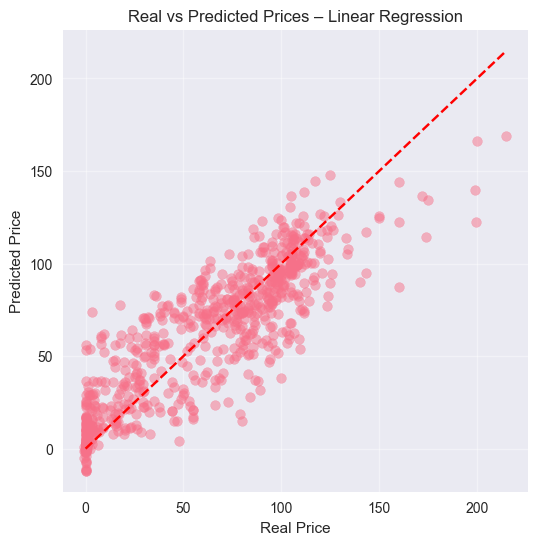

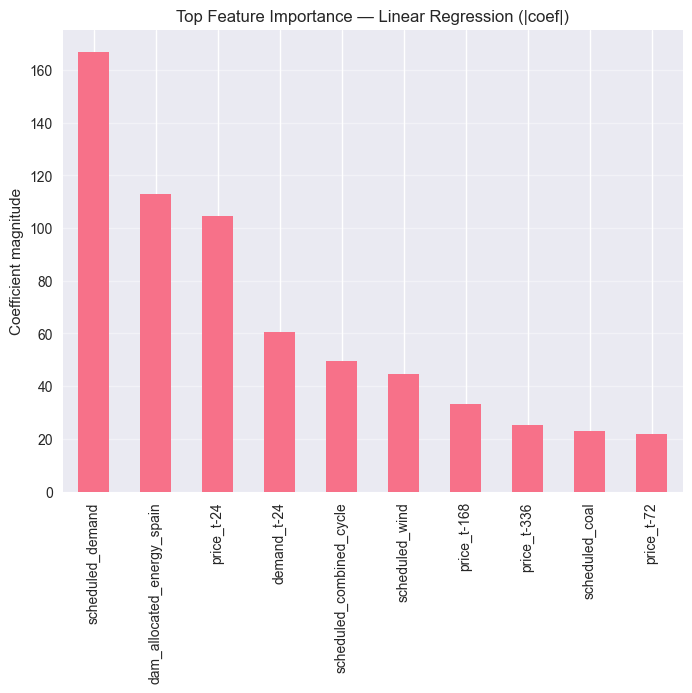

In [89]:
# Scatter Real vs Predict
plt.figure(figsize=(6,6))
plt.scatter(y_test_final, y_pred_test, alpha=0.5)
plt.plot([0, max(y_test_final)], [0, max(y_test_final)], 'r--')
plt.xlabel("Real Price")
plt.ylabel("Predicted Price")
plt.title("Real vs Predicted Prices – Linear Regression")
plt.grid(True, alpha=0.4)
plt.show()
coef_importance = pd.Series(
    np.abs(final_model.coef_),
    index=feature_cols_final
).sort_values(ascending=False)

plt.figure(figsize=(8,6))
coef_importance.head(10).plot(kind="bar")
plt.title("Top Feature Importance — Linear Regression (|coef|)")
plt.ylabel("Coefficient magnitude")
plt.grid(axis="y", alpha=0.4)
plt.show()

Different machine learning models were implemented and evaluated using the same feature set

The validation results showed that Linear Regression consistently achieved the lowest error values, confirming that the relationship between the selected features and the spot price is mostly linear.

RMSE: 14.46 [eur/MWh]
MAE: 10.69 [eur/MWh]
R2: 0.886

The importance of each feature was analyzed using the absolute value of the regression coefficients. Results show that the dominant drivers of spot price are: Scheduled demand, DAM allocated energy, Recent spot prices, Scheduled combined cycle generation

Demand indicators and marginal gas-based generation strongly influence short-term price formation.

# Task 3 — Clustering Daily Electricity Price Profiles

This task applies unsupervised learning techniques to identify patterns in the daily
Spanish spot electricity price. 
There will be two perspectives to understand how market fundamentals shape intraday
price behavior.

1. **Shape-based clustering (24-hour price curves)**  
   Each day is represented by its 24-hour price vector.  
   This reveals recurring intraday price shapes.

2. **Feature-based clustering (market fundamentals)**  
   Each day is represented using engineered features derived from:
   - price level and volatility  
   - system demand  
   - renewable and thermal generation  
   - price spikes  
   - cyclical calendar effects (month, day of week)  




k=2, silhouette=0.462
k=3, silhouette=0.354
k=4, silhouette=0.332
k=5, silhouette=0.282
k=6, silhouette=0.294
k=7, silhouette=0.291
k=8, silhouette=0.232

Best k: 2


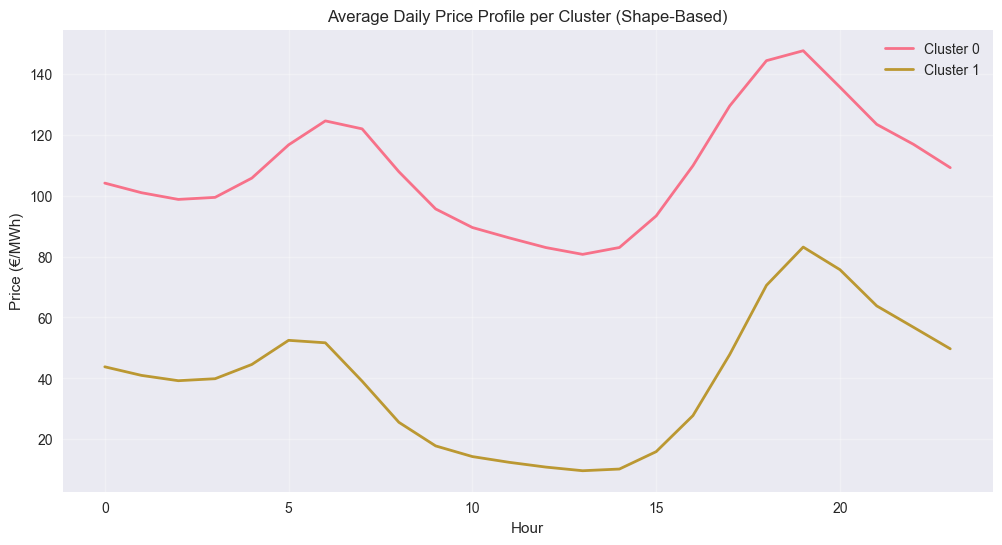

In [90]:
# Daily 24-hour matrix
df_daily = Dataset_indexed.copy()

daily_matrix = df_daily["spot_price_spain"].groupby(df_daily.index.date).apply(
    lambda x: x.values if len(x) == 24 else np.nan
).dropna()

daily_df = pd.DataFrame(
    daily_matrix.tolist(),
    index=pd.to_datetime(daily_matrix.index),
    columns=[f"h{h}" for h in range(24)]
)

# --- Scale the 24h profiles ---
scaler = StandardScaler()
daily_df_scaled = scaler.fit_transform(daily_df)

# --- Silhouette search for optimal K ---
sil_scores = {}
for k in range(2, 9):
    labels = KMeans(n_clusters=k, random_state=42).fit_predict(daily_df_scaled)
    sil_scores[k] = silhouette_score(daily_df_scaled, labels)
    print(f"k={k}, silhouette={sil_scores[k]:.3f}")

best_k = max(sil_scores, key=sil_scores.get)
print("\nBest k:", best_k)

# --- Final clustering ---
kmeans_final = KMeans(n_clusters=best_k, random_state=42)
daily_df["cluster_shape"] = kmeans_final.fit_predict(daily_df_scaled)

# --- Plot cluster mean profiles ---
plt.figure(figsize=(12,6))
for c in sorted(daily_df["cluster_shape"].unique()):
    profile = daily_df[daily_df["cluster_shape"] == c].iloc[:, :24].mean()
    plt.plot(range(24), profile, linewidth=2, label=f"Cluster {c}")

plt.legend()
plt.grid(alpha=0.3)
plt.xlabel("Hour")
plt.ylabel("Price (€/MWh)")
plt.title("Average Daily Price Profile per Cluster (Shape-Based)")
plt.show()


### Interpretation of Shape-Based Clusters

The shape-based clustering identifies two distinct daily price regimes that share
a similar intraday structure but differ significantly in price level.

Cluster 0 represents a high-price regime, characterised by elevated prices
throughout the day and a evening peak (at 19). This profile is consistent with
tight system conditions, where thermal generation is frequently marginal.

Cluster 1 corresponds to a low-price regime, with a strong midday price depression
driven by high solar generation and a milder evening peak. These days reflect
high renewable penetration and better system conditions.





k=2, silhouette=0.151
k=3, silhouette=0.144
k=4, silhouette=0.150
k=5, silhouette=0.150
k=6, silhouette=0.156
k=7, silhouette=0.166
Best k (feature-based): 7


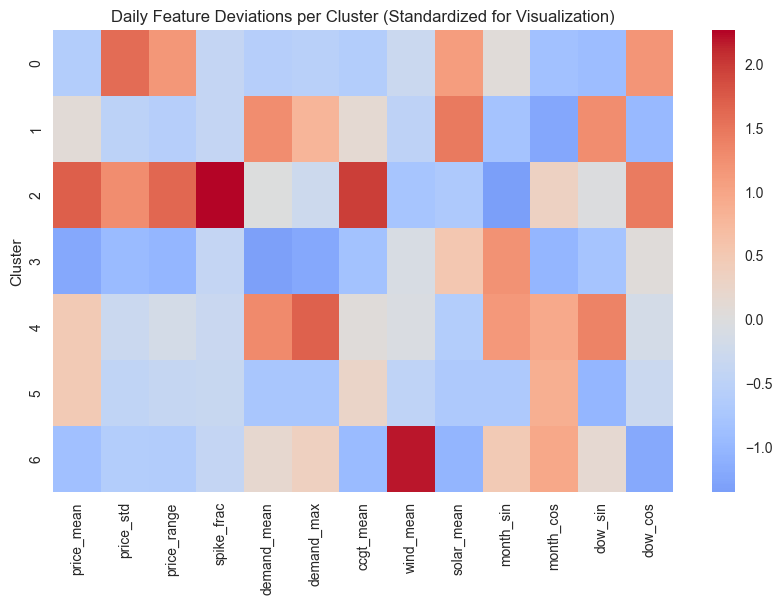

In [ ]:
#from sklearn.preprocessing import StandardScaler
#from sklearn.cluster import KMeans
#from sklearn.metrics import silhouette_score

# --- Working copy ---
df = Dataset_indexed.copy()
df["date"] = df.index.date
df["is_spike"] = df["spot_price_spain"] > 200

# --- Daily aggregation ---
daily_feat = df.groupby("date").agg(
    price_mean=("spot_price_spain", "mean"),
    price_std=("spot_price_spain", "std"),
    price_min=("spot_price_spain", "min"),
    price_max=("spot_price_spain", "max"),
    demand_mean=("actual_national_demand", "mean"),
    demand_max=("actual_national_demand", "max"),
    ccgt_mean=("actual_combined_cycle_generation", "mean"),
    wind_mean=("actual_wind_generation", "mean"),
    solar_mean=("actual_solar_pv_generation", "mean"),
    spike_frac=("is_spike", "mean")
)

daily_feat.index = pd.to_datetime(daily_feat.index)

# Additional engineered features
daily_feat["price_range"] = daily_feat["price_max"] - daily_feat["price_min"]
daily_feat["month"] = daily_feat.index.month
daily_feat["day_of_week"] = daily_feat.index.dayofweek

# --- Cyclical encoding ---
daily_feat["month_sin"] = np.sin(2 * np.pi * daily_feat["month"] / 12)
daily_feat["month_cos"] = np.cos(2 * np.pi * daily_feat["month"] / 12)
daily_feat["dow_sin"] = np.sin(2 * np.pi * daily_feat["day_of_week"] / 7)
daily_feat["dow_cos"] = np.cos(2 * np.pi * daily_feat["day_of_week"] / 7)



# Remove raw calendar fields
daily_feat = daily_feat.drop(columns=["month", "day_of_week"])

# Feature list
feature_cols_cluster = [
    "price_mean", "price_std", "price_range",
    "spike_frac",
    "demand_mean", "demand_max",
    "ccgt_mean", "wind_mean", "solar_mean",
    "month_sin", "month_cos",
    "dow_sin", "dow_cos"
]

# --- Scaling ---
X_feat = daily_feat[feature_cols_cluster].fillna(0)
scaler_feat = StandardScaler()
X_feat_scaled = scaler_feat.fit_transform(X_feat)

# --- Silhouette selection ---
sil_scores_feat = {}
for k in range(2, 8):
    labels = KMeans(n_clusters=k, random_state=42).fit_predict(X_feat_scaled)
    sil_scores_feat[k] = silhouette_score(X_feat_scaled, labels)
    print(f"k={k}, silhouette={sil_scores_feat[k]:.3f}")

best_k_feat = max(sil_scores_feat, key=sil_scores_feat.get)
print("Best k (feature-based):", best_k_feat)

# --- Final clustering ---
kmeans_feat = KMeans(n_clusters=best_k_feat, random_state=42)
daily_feat["cluster_feat"] = kmeans_feat.fit_predict(X_feat_scaled)

# --- Cluster summary ---
# Normalize per feature (column-wise) only for visualization
cluster_summary = daily_feat.groupby("cluster_feat")[feature_cols_cluster].mean()

cluster_summary_norm = (
    cluster_summary - cluster_summary.mean()
) / cluster_summary.std()

plt.figure(figsize=(10,6))
sns.heatmap(
    cluster_summary_norm,
    cmap="coolwarm",
    center=0,
    annot=False
)
plt.title("Daily Feature Deviations per Cluster (Standardized for Visualization)")
plt.ylabel("Cluster")
plt.show()



## Interpretation of Feature-Based Clusters

The feature-based clustering groups **days** into distinct market regimes,
characterised by different combinations of demand levels, generation mix, and
price behaviour.

Some clusters reflect **high-stress system conditions**, with above-average
prices, higher volatility, elevated demand, and stronger reliance on
combined-cycle gas turbines (CCGT), often combined with lower renewable output.
These regimes also show a higher incidence of price spikes (e.g., **Cluster 2**).

Other clusters represent **renewable-dominated, low-price conditions**, where
high wind and/or solar generation is associated with lower price levels and
reduced volatility, even under moderate demand. This pattern is visible in
clusters dominated by high wind production (e.g., **Cluster 6**) and in clusters
with high solar and moderate wind generation (e.g., **Cluster 3**).


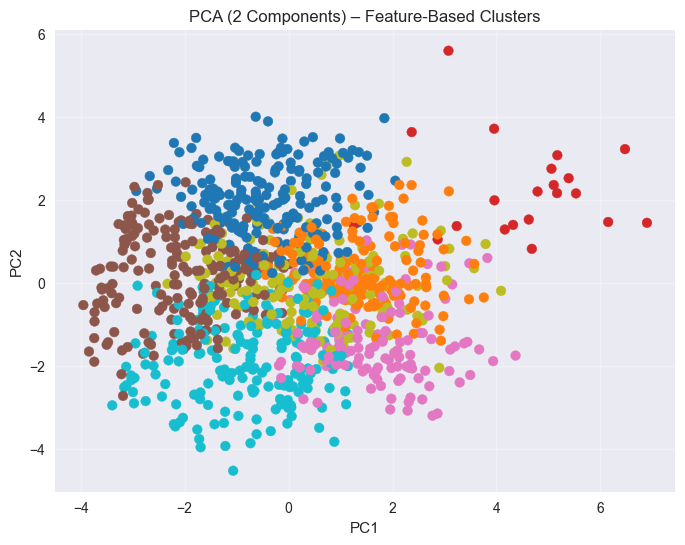

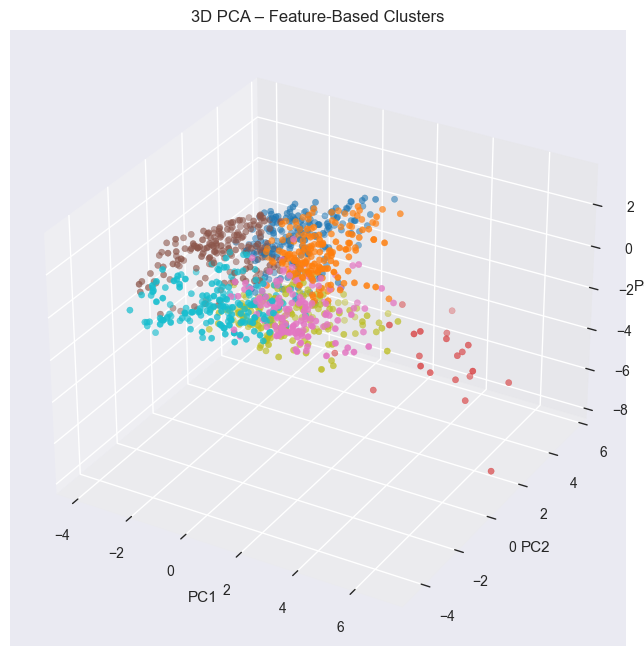

,price_mean,price_std,price_range,spike_frac,demand_mean,demand_max,ccgt_mean,wind_mean,solar_mean,month_sin,month_cos,dow_sin,dow_cos
PC1,0.465666,0.112596,0.164279,0.234594,0.411298,0.376798,0.453719,-0.171403,0.010238,-0.222291,0.097305,0.286888,-0.027949
PC2,0.012483,0.450168,0.412473,0.127918,-0.228574,-0.279781,0.064800,-0.344805,0.387809,-0.187238,-0.351237,-0.178355,0.128266
PC3,-0.259805,-0.021995,-0.060873,-0.300487,0.363820,0.320309,-0.182002,-0.011494,0.503329,0.148057,-0.445191,0.285485,-0.121826


In [92]:
from sklearn.decomposition import PCA

# PCA with 2 components
pca2 = PCA(n_components=2)
coords2 = pca2.fit_transform(X_feat_scaled)

plt.figure(figsize=(8,6))
plt.scatter(coords2[:,0], coords2[:,1], c=daily_feat["cluster_feat"], cmap="tab10")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA (2 Components) – Feature-Based Clusters")
plt.grid(alpha=0.3)
plt.show()

# PCA with 3 components for DBSCAN
pca3 = PCA(n_components=3)
X_pca3 = pca3.fit_transform(X_feat_scaled)

#plot 3D PCA
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca3[:,0], X_pca3[:,1], X_pca3[:,2], c=daily_feat["cluster_feat"], cmap="tab10")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D PCA – Feature-Based Clusters")
plt.show()


loadings = pd.DataFrame(
    pca3.components_,
    columns=feature_cols_cluster,
    index=["PC1", "PC2", "PC3"]
)

loadings





## Final Conclusions

This analysis applied two complementary clustering approaches to the Spanish
day-ahead electricity price:

### 1. Shape-Based Clustering  
Daily price profiles (24-hour curves) reveal a limited number of recurring
intraday regimes.
These clusters capture **how prices evolve within the day**.

### 2. Feature-Based Clustering  
Clustering based on daily aggregated fundamentals identifies broader **market
regimes** driven by demand levels, generation mix, and price volatility.
Distinct regimes emerge, ranging from renewable-dominated, low-price days to
high-stress system conditions characterised by high demand, strong CCGT
dispatch, and frequent price spikes. From this analysis it was more understandable the prices behaviour.

### 3. PCA Analysis  
PCA applied to the feature-based clustering confirms that:
- **PC1** captures overall system stress and price level, driven by demand intensity and CCGT marginality.

- **PC2** may represents price volatility and intraday amplitude, largely associated with solar-driven price swings and reduced wind contribution.

- **PC3** may reflects seasonal and calendar-related structure, distinguishing renewable-rich periods with lower average prices and fewer spikes.

The PCA projections show a clear separation between clusters, supporting the
robustness of the identified regimes.


# Task 4 — PCA for the regression model

Number of PCA components: 11
Explained variance: 96.95 %
PCA Regression Metrics
RMSE = 22.49
MAE  = 17.21
R²   = 0.725


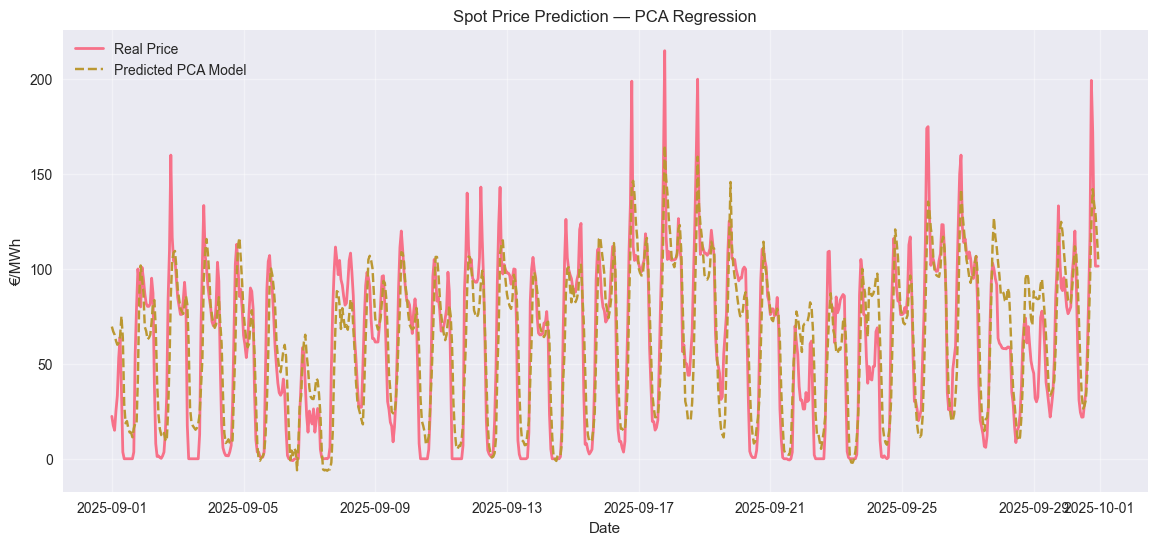

In [93]:
#TASK 4) Train and test the regression model using PCA for the input data.
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# feature scaling
scaler_pca = StandardScaler()
X_train_scaled_pca = scaler_pca.fit_transform(X_train_final)
X_test_scaled_pca  = scaler_pca.transform(X_test_final)

# Fitting
pca = PCA(n_components=0.95) #keeps 95% of variance
pca.fit(X_train_scaled_pca)

print("Number of PCA components:", pca.n_components_)
print(f"Explained variance: {pca.explained_variance_ratio_.sum()*100:.2F} %")

X_train_pca = pca.transform(X_train_scaled_pca)
X_test_pca  = pca.transform(X_test_scaled_pca)

# Linear regression for PCA
pca_model = LinearRegression()
pca_model.fit(X_train_pca, y_train_final)

y_pred_pca = pca_model.predict(X_test_pca)

# Evaluation
rmse_pca = np.sqrt(mean_squared_error(y_test_final, y_pred_pca))
mae_pca  = mean_absolute_error(y_test_final, y_pred_pca)
r2_pca   = r2_score(y_test_final, y_pred_pca)

print("PCA Regression Metrics")
print(f"RMSE = {rmse_pca:.2f}")
print(f"MAE  = {mae_pca:.2f}")
print(f"R²   = {r2_pca:.3f}")


plt.figure(figsize=(14,6))
plt.plot(y_test_final.index, y_test_final.values, label="Real Price", linewidth=2)
plt.plot(y_test_final.index, y_pred_pca, label="Predicted PCA Model", linestyle="--")
plt.title("Spot Price Prediction — PCA Regression")
plt.ylabel("€/MWh")
plt.xlabel("Date")
plt.legend()
plt.grid(alpha=0.4)
plt.show()


# What are the main differences between the 2 model results?

Applying PCA (Principal Component Analysis) to the input features resulted in 11 retained components with a variance of 96.95%

This means that PCA was able to compress the original 14 features into 11 components while preserving most of the variance.

After transforming the training and test sets using PCA and fitting a Linear Regression model, the metrics obtained were:

    For regression with PCA: RMSE 22.49 / MAE 17.21 / R2 0.725
    Original model: RMSE 14.46 / MAE 10.69 / R2 0.886

With PCA the performance is worse and it could be because:
- it destroys feature interpretability. The original features have physical meaning related to market fundamentals, and so when they are transformed into abstract variables, the model loses the direct relationship between each predictor and the price formation process.

- PCA enforces orthogonality that doesn't exist in the system. As the electricity market drivers are correlated by nature, PCA forces them to become orthogonal, breaking the structure that the regression model exploits.

- it doesn't keep relevance, only variance. So, even if a component captures variance, it may not correlate with the target. Meaning that PCA optimizes feature compression but not prediction accuracy.



The PCA-predicted curve follows the general daily shape but underestimates the peaks, as well as the valleys or low-price hours.


In conclusion, the used of PCA before regression reduces significantly the model's accuracy. As it compresses the features and removes multicollinearity, it also omits the tructure between the considered variables and the target price. Resulting in that the PCA-based captures only 72% of the variance in the test data with worse metrics than the previous model. In this case, PCA is not beneficial as the original features contain physically meaningful information, and the LR model performs best without it.